[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/subramanyanaik/schoolofai_subbu/blob/main/assignment12/zero_harness.ipynb)

Generated from [`zero_harness.py`](zero_harness.py) by `tools/build_notebook.py` - edit the `.py`, not this file.

# Session 12 — 32 virtual GPUs, and what ZeRO actually costs

The assignment is to build 32 virtual GPUs, run a model on top of them, simulate ZeRO-1,
ZeRO-2 and ZeRO-3, and show how memory and computation change.

The easy version of this is to type the DeepSpeed formula into a spreadsheet:
`16Ψ` for plain data parallelism, `4Ψ + 12Ψ/N` for ZeRO-1, `2Ψ + 14Ψ/N` for ZeRO-2,
`16Ψ/N` for ZeRO-3, print a table, done. That version cannot be wrong, because it never
touches anything. It also teaches nothing, and it hides the four things that actually
decide whether a training run fits and how fast it goes.

So nothing in this notebook is a formula evaluated. Every number is produced by running
something:

* **The 32 GPUs are real objects with a hard memory limit.** Every tensor a rank owns is
  allocated through a ledger that refuses the allocation when the rank is out of room.
  "ZeRO-3 fits a bigger model" is demonstrated by *bisecting until each stage OOMs*, not
  by dividing by 32.
* **The collectives are real ring algorithms** run across 32 Python threads, with a
  barrier per ring step. The communication volume is counted at the point where a chunk
  moves from one rank to the next, so `2Ψ` is a *measurement*, and it comes out slightly
  under `2Ψ`, for a reason the formula does not mention.
* **The gradients are real gradients** from a real GPT trained on real text. All four
  stages are checked, weight by weight, against a single-GPU run that accumulates the same
  global batch — because a sharded trainer that does not reproduce the unsharded one is
  not an optimisation, it is a bug.
* **The topology is real.** 32 GPUs = 4 nodes × 8, NVLink inside a node, InfiniBand
  between them, at the bandwidths from the session. The time model is arithmetic over
  measured bytes, and it is labelled as a model everywhere it appears.

Four of the results were not what I expected going in, and they are the parts worth
reading: what ZeRO-3's peak memory is actually set by (§7), which of the stages turn out
to be free (§10), where ZeRO-1 still keeps a full copy of the gradient (§5), and what
happens to the whole ranking when the 32 GPUs stop being in one box (§10).

This file is the single source of truth. `tools/build_notebook.py` turns it, cell for
cell, into `zero_harness.ipynb`, and CI fails if the two drift. Every number quoted in
`README.md` is read out of `results/results.json`, which this run writes.

In [1]:
# ---------------------------------------------------------------------------------------
# Setup.  torch, numpy, matplotlib; everything else is stdlib.
# ---------------------------------------------------------------------------------------
import json
import math
import os
import sys
import threading
import time
import urllib.request

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib

IN_NOTEBOOK = "ipykernel" in sys.modules
if not IN_NOTEBOOK:                       # headless script run
    matplotlib.use("Agg")
import matplotlib.pyplot as plt


def show(fig):
    """Display inline in a notebook; close silently in a headless script run."""
    if IN_NOTEBOOK:
        plt.show()
    else:
        plt.close(fig)


RESULTS = {}          # every number the write-up quotes ends up in here

try:                                      # running as a script
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:                         # running as a notebook
    HERE = os.getcwd()
OUT_DIR = os.path.join(HERE, "results")
os.makedirs(OUT_DIR, exist_ok=True)

T_START = time.time()
if not IN_NOTEBOOK:                       # so a redirected log is UTF-8, not cp1252
    try:
        sys.stdout.reconfigure(encoding="utf-8")
    except Exception:
        pass


def rule(title):
    el = time.time() - T_START
    print("\n" + "=" * 92)
    print(f"{title}   [t+{int(el) // 60:d}m{int(el) % 60:02d}s]")
    print("=" * 92)


def record(key, value):
    RESULTS[key] = value
    return value


SEED = 1337
torch.manual_seed(SEED)
np.random.seed(SEED)

# The virtual GPUs are threads, and each one runs torch ops.  One intra-op thread each,
# or 32 workers on 16 cores spend their time fighting over the same cores.
torch.set_num_threads(1)

rule("Environment")
print(f"python        : {sys.version.split()[0]}")
print(f"torch         : {torch.__version__}")
print(f"host cpu cores: {os.cpu_count()}")
record("torch_version", torch.__version__)
record("host_cores", os.cpu_count())
record("seed", SEED)
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"host gpu      : {props.name} ({props.total_memory / 2**30:.2f} GiB) "
          f"-- present, and deliberately unused: see the note below")
    record("host_gpu", props.name)
    record("host_gpu_gib", round(props.total_memory / 2**30, 2))
else:
    record("host_gpu", None)

MIB = 2 ** 20
GIB = 2 ** 30


Environment   [t+0m00s]
python        : 3.12.6
torch         : 2.5.1+cu121
host cpu cores: 16


host gpu      : NVIDIA GeForce RTX 3050 Laptop GPU (4.00 GiB) -- present, and deliberately unused: see the note below


## 1. What a "virtual GPU" is here

The session's hardware picture is the thing being modelled, so the model keeps its shape:

| | |
|---|---|
| a **node** is a physical box | 8 GPUs in it, always |
| 32 GPUs | therefore **4 nodes**, and `world_size = 32` |
| inside a node | NVLink, ~450 GB/s |
| between nodes | InfiniBand, ~50 GB/s — *nine times slower*, which is the fact the whole second half of this notebook turns on |
| each GPU | a fixed amount of memory it cannot exceed |

A `VirtualGPU` here is three things: a rank, the node it sits in, and a **memory ledger
with a hard ceiling**. Every tensor a rank owns is created through `mem.alloc(...)`, which
adds its true byte count (`numel × element_size`, asked of the tensor, not assumed) to a
running total, updates the rank's high-water mark, and raises `DeviceOOM` if the rank has
run out of room. Freeing a tensor goes through `mem.free(...)`.

That ceiling is the single most important design decision in this notebook. It is what
turns "ZeRO-3 lets you fit a bigger model" from a claim into an experiment: §8 grows the
model until each stage stops fitting, and reports the largest one that actually trained.

**The ceiling is 8 MiB, not 80 GiB, and that is on purpose.** 32 ranks × the state of an
80 GiB-class model is several terabytes; this laptop has 16. So every GPU is scaled down
by a fixed factor of 10,240 and *everything else is left alone* — the model is scaled to
match, the bandwidths are the real ones, and the ratios that ZeRO is about (bytes per
parameter, bytes moved per parameter, memory per rank ÷ memory on one rank) are
dimensionless and survive the scaling exactly. §12 pushes the measured coefficients back
up and checks them against the session's own 30B/447 GiB table.

The host GPU goes unused for exactly this reason: 32 replicas of anything do not fit in
4 GiB, and the quantities being measured — bytes allocated, bytes moved — are integers
that do not care which device holds the tensor. The session said "CPU threads or Colab
GPU"; on this machine CPU threads are the ones that can hold 32 of anything.

In [2]:
class DeviceOOM(RuntimeError):
    """Raised when a rank asks for memory its virtual GPU does not have."""


class DeviceMemory:
    """A per-rank allocator that knows its own capacity and keeps a high-water mark.

    Every byte the simulation charges to a GPU passes through here, tagged with a category,
    so the memory tables later are a read-out of this ledger rather than a formula.
    """

    CATEGORIES = ("params", "grads", "optimizer", "activations", "comm", "other")

    def __init__(self, rank, capacity_bytes):
        self.rank = rank
        self.capacity = capacity_bytes
        self.live = {}                                     # name -> (bytes, category)
        self.used = 0
        self.peak = 0
        self.by_cat = {c: 0 for c in self.CATEGORIES}
        self.peak_by_cat = {c: 0 for c in self.CATEGORIES}
        self.peak_snapshot = None                          # by_cat at the moment of peak
        self.n_allocs = 0
        self.oom_at = None

    def alloc(self, name, tensor, category="other"):
        nbytes = tensor.numel() * tensor.element_size()
        return self.charge(name, nbytes, category, tensor)

    def charge(self, name, nbytes, category="other", tensor=None):
        assert category in self.by_cat, category
        assert name not in self.live, f"rank {self.rank}: '{name}' allocated twice"
        if self.used + nbytes > self.capacity:
            self.oom_at = (name, nbytes, self.used)
            raise DeviceOOM(
                f"rank {self.rank}: '{name}' needs {nbytes / MIB:.2f} MiB, "
                f"{(self.capacity - self.used) / MIB:.2f} MiB free of "
                f"{self.capacity / MIB:.2f} MiB")
        self.live[name] = (nbytes, category)
        self.used += nbytes
        self.by_cat[category] += nbytes
        self.n_allocs += 1
        if self.used > self.peak:
            self.peak = self.used
            self.peak_snapshot = dict(self.by_cat)
        self.peak_by_cat[category] = max(self.peak_by_cat[category], self.by_cat[category])
        return tensor

    def free(self, name):
        if name not in self.live:
            return
        nbytes, category = self.live.pop(name)
        self.used -= nbytes
        self.by_cat[category] -= nbytes

    def free_prefix(self, prefix):
        for name in [n for n in self.live if n.startswith(prefix)]:
            self.free(name)

    def reset_peak(self):
        self.peak = self.used
        self.peak_snapshot = dict(self.by_cat)
        self.peak_by_cat = {c: self.by_cat[c] for c in self.CATEGORIES}


class VirtualGPU:
    """One of the 32.  A rank, the node it lives in, its memory, and its local state."""

    def __init__(self, rank, gpus_per_node, capacity_bytes):
        self.rank = rank
        self.node = rank // gpus_per_node
        self.local_rank = rank % gpus_per_node
        self.mem = DeviceMemory(rank, capacity_bytes)
        self.state = {}            # whatever the training strategy wants to keep here

    def __repr__(self):
        return (f"<GPU {self.rank:2d} node {self.node} "
                f"{self.mem.used / MIB:6.2f}/{self.mem.capacity / MIB:.0f} MiB>")

## 2. The interconnect, and why the collectives are implemented rather than costed

Three collectives carry all of data parallelism, and ZeRO is a statement about which of
them you run:

| | what it does | who ends up with what |
|---|---|---|
| **all-reduce** | combines a value from every GPU | *every* GPU gets the whole combined result |
| **reduce-scatter** | combines it the same way | every GPU gets **one slice** of the result — 1/32 each |
| **all-gather** | the reverse | every GPU contributes its slice and ends up with the whole thing |

and the identity the entire rest of the notebook rests on:

> **all-reduce = reduce-scatter + all-gather.**

That is not a coincidence, it is how a ring all-reduce is *built*. Which means DDP was
always paying for both halves — and ZeRO-1 and ZeRO-2 get to shard state for free by
noticing that there is a moment, between the two halves, when every rank is already
holding exactly 1/32 of the reduced gradient and nothing else. Everything ZeRO-1 and
ZeRO-2 do happens in that gap.

So the ring is written out properly, 2(N-1) steps of Psi/N bytes each, with a real barrier
per step and a real copy at each hop, and the byte counter increments where a chunk crosses
from rank r to rank r+1. Two things fall out of that which a formula would have hidden:

1. the per-rank volume of an all-reduce is **2Psi(N-1)/N**, not 2Psi — at N=32 that is
   1.9375Psi, and the gap is the one chunk you never have to send to yourself;
2. a ring laid flat across 4 nodes contains **4 inter-node hops**, and a ring is only as
   fast as its slowest hop, so a flat 32-way collective runs at InfiniBand speed *end to
   end* even though 28 of its 32 links are NVLink. Section 9 measures what that costs and
   what the hierarchical version buys back.

`Group` is a ring over any subset of ranks with its own barrier, which is what makes the
hierarchical version implementable rather than assertable: the intra-node rings are groups
of 8, the inter-node ring is a group of the 4 node leaders.

In [3]:
class Group:
    """A ring of ranks with its own barrier.

    Every collective is built out of one primitive: each member sends a chunk to its ring
    successor and receives one from its predecessor.
    """

    def __init__(self, fabric, members, name):
        self.fabric = fabric
        self.members = list(members)
        self.size = len(self.members)
        self.name = name
        self.index = {r: i for i, r in enumerate(self.members)}
        self.barrier = threading.Barrier(self.size) if self.size > 1 else None
        self.slots = [[None] * self.size, [None] * self.size]
        # The ring's links, and therefore its speed: the successor of member i is member i+1.
        self.links = []
        for i, r in enumerate(self.members):
            nxt = self.members[(i + 1) % self.size]
            same_node = (r // fabric.gpus_per_node) == (nxt // fabric.gpus_per_node)
            self.links.append("nvlink" if same_node else "ib")
        self.n_inter = sum(1 for link in self.links if link == "ib")
        # A ring step finishes when its slowest link finishes.
        self.bw = fabric.bw_inter if self.n_inter else fabric.bw_intra
        self.latency = fabric.lat_inter if self.n_inter else fabric.lat_intra

    def _exchange(self, rank, chunk, step):
        """Send `chunk` to the ring successor; return what the predecessor sent.

        Two barriers, not one.  The first is a gate: it guarantees every member has finished
        *reading* the previous step's slot before anyone overwrites it.  Without it the ring
        is correct inside a single collective and silently corrupts across back-to-back
        ones -- the last step of one all-reduce and the first step of the next both land on
        the same slot, and a fast rank overwrites a buffer a slow rank has not read yet.
        That failure does not look like a race; it looks like a tensor-shape mismatch 60
        collectives later.

        The clone is not a formality either: it is the copy that a send physically is, and
        it is the point at which the byte counter increments.
        """
        i = self.index[rank]
        self.barrier.wait()
        self.slots[0][i] = chunk.clone()
        self.fabric.note_hop(rank, chunk.numel() * chunk.element_size(),
                             self.links[i], self.name)
        self.barrier.wait()
        return self.slots[0][(i - 1) % self.size]

    def _charge_time(self, rank, chunk_bytes, steps):
        """Model the wall-clock this ring would take on the hardware being modelled.

        Every member runs its step concurrently, so a step costs one chunk over the ring's
        slowest link, not `size` chunks.  Charged once, by the first member.
        """
        # Charged by rank 0 only.  The node rings and the rail rings run *concurrently*, so
        # billing once per group would count the same seconds four and eight times over;
        # rank 0 passes through exactly one instance of each phase, which is the wall-clock.
        if rank == 0:
            self.fabric.comm_seconds += steps * (chunk_bytes / self.bw + self.latency)

    # ---- the three collectives -------------------------------------------------------
    def reduce_scatter(self, rank, buf):
        """`buf` is the full vector on every member; returns this member's reduced slice.

        N-1 steps of Psi/N.  The index shift is chosen so member i finishes holding chunk
        i, which is the convention NCCL uses and the one the sharded stages assume.
        """
        if self.size == 1:
            return buf.clone()
        n = buf.numel()
        assert n % self.size == 0, f"{n} is not divisible by {self.size}"
        chunks = buf.view(self.size, n // self.size)
        i = self.index[rank]
        for step in range(self.size - 1):
            send = (i - step - 1) % self.size
            recv = (i - step - 2) % self.size
            incoming = self._exchange(rank, chunks[send], step)
            chunks[recv] += incoming
        self._charge_time(rank, chunks[0].numel() * buf.element_size(), self.size - 1)
        return chunks[i].clone()

    def all_gather_into(self, rank, buf):
        """Every member arrives holding its own slice in place inside `buf`, and leaves
        holding all of `buf`.  N-1 steps of Psi/N."""
        if self.size == 1:
            return buf
        n = buf.numel()
        assert n % self.size == 0, f"{n} is not divisible by {self.size}"
        chunks = buf.view(self.size, n // self.size)
        i = self.index[rank]
        for step in range(self.size - 1):
            send = (i - step) % self.size
            recv = (i - step - 1) % self.size
            incoming = self._exchange(rank, chunks[send], step)
            chunks[recv].copy_(incoming)
        self._charge_time(rank, chunks[0].numel() * buf.element_size(), self.size - 1)
        return buf

    def all_reduce(self, rank, buf):
        """reduce-scatter followed by all-gather: the identity, run rather than quoted."""
        if self.size == 1:
            return buf
        n = buf.numel()
        chunks = buf.view(self.size, n // self.size)
        i = self.index[rank]
        chunks[i].copy_(self.reduce_scatter(rank, buf))
        return self.all_gather_into(rank, buf)


class Fabric:
    """The wiring between the virtual GPUs, and the meter on it."""

    def __init__(self, world_size, gpus_per_node=8,
                 bw_intra=450e9, bw_inter=50e9, lat_intra=5e-6, lat_inter=10e-6):
        self.world = world_size
        self.gpus_per_node = min(gpus_per_node, world_size)
        self.n_nodes = math.ceil(world_size / self.gpus_per_node)
        self.bw_intra, self.bw_inter = bw_intra, bw_inter
        self.lat_intra, self.lat_inter = lat_intra, lat_inter
        self._lock = threading.Lock()
        self.reset_counters()
        self.world_group = Group(self, range(world_size), "world")
        self.node_groups = {}
        for node in range(self.n_nodes):
            members = [r for r in range(world_size) if r // self.gpus_per_node == node]
            self.node_groups[node] = Group(self, members, f"node{node}")
        # The cross-node rings are "rails": all the local-rank-j GPUs, one per node.  There
        # are `gpus_per_node` of them and they run at the same time, which is the whole
        # point -- a design where only the node leaders talk across nodes reduces one chunk
        # in eight and silently leaves the other seven node-local.
        self.rail_groups = {j: Group(self, [n * self.gpus_per_node + j
                                            for n in range(self.n_nodes)], f"rail{j}")
                            for j in range(self.gpus_per_node)}

    def reset_counters(self):
        self.bytes_per_rank = [0] * self.world
        self.bytes_by_link = {"nvlink": 0, "ib": 0}
        self.hops = 0
        self.comm_seconds = 0.0
        self.by_op = {}

    def note_hop(self, rank, nbytes, link, opname):
        with self._lock:
            self.bytes_per_rank[rank] += nbytes
            self.bytes_by_link[link] += nbytes
            self.hops += 1
            self.by_op[opname] = self.by_op.get(opname, 0) + nbytes

    # ---- what a training strategy calls ----------------------------------------------
    def all_reduce(self, rank, buf):
        return self.world_group.all_reduce(rank, buf)

    def reduce_scatter(self, rank, buf):
        return self.world_group.reduce_scatter(rank, buf)

    def all_gather_into(self, rank, buf):
        return self.world_group.all_gather_into(rank, buf)

    def all_reduce_hierarchical(self, rank, buf):
        """NVLink inside each node; InfiniBand only between node leaders, and only on 1/8 of
        the data.  The same arithmetic as the flat ring, and a very different bill."""
        if self.n_nodes == 1 or self.world == 1:
            return self.all_reduce(rank, buf)
        node = self.node_groups[rank // self.gpus_per_node]
        i = node.index[rank]
        n = buf.numel()
        chunks = buf.view(node.size, n // node.size)
        # 1. reduce-scatter inside the box, on NVLink: rank i ends up with the node's
        #    partial sum of chunk i.
        chunks[i].copy_(node.reduce_scatter(rank, buf))
        # 2. all-reduce chunk i across the nodes, on InfiniBand, but only 1/8 of the data,
        #    and all eight rails do it at once.
        rail = self.rail_groups[i]
        piece = chunks[i].clone()
        rail.all_reduce(rank, piece)
        chunks[i].copy_(piece)
        # 3. all-gather inside the box again.
        return node.all_gather_into(rank, buf)

    def run(self, fn, world=None):
        """Run `fn(rank)` on every rank at once, each on its own thread.  Returns the results
        in rank order, and re-raises whatever a rank raised."""
        world = world or self.world
        out, errs = [None] * world, [None] * world

        def worker(rank):
            try:
                torch.set_num_threads(1)
                out[rank] = fn(rank)
            except BaseException as e:      # one rank failing must not hang the other 31
                errs[rank] = e
                for g in self.all_groups():
                    if g.barrier is not None:
                        g.barrier.abort()

        threads = [threading.Thread(target=worker, args=(r,), name=f"gpu{r}")
                   for r in range(world)]
        for t in threads:
            t.start()
        for t in threads:
            t.join()
        # A broken barrier is the symptom, not the disease: report the rank that actually
        # failed, and only fall back to the barrier error if that is all there is.
        for e in errs:
            if e is not None and not isinstance(e, threading.BrokenBarrierError):
                raise e
        for e in errs:
            if e is not None:
                raise e
        self.reset_barriers()
        return out

    def all_groups(self):
        return ([self.world_group] + list(self.node_groups.values())
                + list(self.rail_groups.values()))

    def reset_barriers(self):
        for g in self.all_groups():
            if g.barrier is not None and g.barrier.broken:
                g.barrier.reset()

### The 32 GPUs, and a fabric that has to prove itself first

Before anything is measured *with* this machinery, the machinery is checked: a ring that
gets the arithmetic wrong would make every later number wrong in a way that still looks
plausible. Four checks, all of which have to pass:

1. the ring all-reduce equals a naive sum over the 32 ranks;
2. reduce-scatter followed by all-gather equals the all-reduce — the identity, run;
3. the measured per-rank volume matches the ring's own theory, `2Psi(N-1)/N`;
4. the hop count matches `N x 2(N-1)` — every rank, every step.

In [4]:
WORLD = 32
GPUS_PER_NODE = 8
GPU_CAPACITY = 8 * MIB          # the scaled-down stand-in for an 80 GiB card
SCALE_TO_80GIB = (80 * GIB) / GPU_CAPACITY

BW_INTRA = 450e9                # NVLink, inside one box
BW_INTER = 50e9                 # InfiniBand, between boxes

rule("The 32 virtual GPUs")
fabric = Fabric(WORLD, GPUS_PER_NODE, bw_intra=BW_INTRA, bw_inter=BW_INTER)
gpus = [VirtualGPU(r, GPUS_PER_NODE, GPU_CAPACITY) for r in range(WORLD)]

record("world", WORLD)
record("gpus_per_node", GPUS_PER_NODE)
record("n_nodes", fabric.n_nodes)
record("gpu_capacity_mib", GPU_CAPACITY / MIB)
record("scale_to_80gib", round(SCALE_TO_80GIB))
record("bw_intra", BW_INTRA)
record("bw_inter", BW_INTER)
record("bw_ratio", round(BW_INTRA / BW_INTER, 1))
print(f"world size    : {WORLD} GPUs = {fabric.n_nodes} nodes x {GPUS_PER_NODE}")
print(f"per-GPU memory: {GPU_CAPACITY / MIB:.0f} MiB  "
      f"(a real 80 GiB card, scaled down by {SCALE_TO_80GIB:,.0f}x)")
print(f"intra-node    : NVLink   {BW_INTRA / 1e9:.0f} GB/s")
print(f"inter-node    : InfiniBand {BW_INTER / 1e9:.0f} GB/s  "
      f"({BW_INTRA / BW_INTER:.0f}x slower)")
print(f"flat 32-ring  : {fabric.world_group.n_inter} of {WORLD} links cross nodes, so the "
      f"whole ring runs at {fabric.world_group.bw / 1e9:.0f} GB/s")
record("flat_ring_inter_links", fabric.world_group.n_inter)

# --- check 1 and 2: the collectives are arithmetically what they claim to be -----------
PSI_PROBE = 32 * 1024                       # elements, divisible by the world size
probe = [torch.randn(PSI_PROBE, dtype=torch.float64) for _ in range(WORLD)]
naive = torch.stack(probe).sum(0)           # the answer, computed the obvious way

fabric.reset_counters()
t0 = time.time()
ar = fabric.run(lambda r: fabric.all_reduce(r, probe[r].clone()))
wall_ar = time.time() - t0
ar_err = max((a - naive).abs().max().item() for a in ar)
ar_digits = min(16.0, -math.log10(max(ar_err, 1e-300) / naive.abs().max().item()))
ar_bytes_per_rank, ar_hops = fabric.bytes_per_rank[0], fabric.hops   # before the next call

rs = fabric.run(lambda r: fabric.reduce_scatter(r, probe[r].clone()))
shard_n = PSI_PROBE // WORLD
rebuilt = torch.zeros(PSI_PROBE, dtype=torch.float64)
for r in range(WORLD):                      # member i finishes holding chunk i
    rebuilt[r * shard_n:(r + 1) * shard_n] = rs[r]
rs_err = (rebuilt - naive).abs().max().item()

probe_bytes = PSI_PROBE * 8
measured_per_rank = ar_bytes_per_rank
theory_per_rank = 2 * probe_bytes * (WORLD - 1) / WORLD
record("ar_digits", round(ar_digits, 1))
record("ar_max_err", ar_err)
record("rs_max_err", rs_err)
record("ar_bytes_per_rank_over_psi", measured_per_rank / probe_bytes)
record("ar_theory_over_psi", 2 * (WORLD - 1) / WORLD)
record("ar_hops", ar_hops)
record("ar_hops_theory", WORLD * 2 * (WORLD - 1))
record("sim_wall_allreduce_ms", round(wall_ar * 1000, 1))

print(f"\nring all-reduce vs naive sum   : agrees to {ar_digits:.1f} digits "
      f"(max abs error {ar_err:.2e})")
print(f"reduce-scatter reassembled     : max abs error {rs_err:.2e}")
print(f"bytes per rank, measured       : {measured_per_rank:,} = "
      f"{measured_per_rank / probe_bytes:.4f} x Psi")
print(f"bytes per rank, ring theory    : {theory_per_rank:,.0f} = "
      f"{2 * (WORLD - 1) / WORLD:.4f} x Psi   <- not 2, and never 2")
print(f"hops, measured / theory        : {ar_hops:,} / "
      f"{WORLD * 2 * (WORLD - 1):,}")
print(f"simulator wall-clock for one   : {wall_ar * 1000:.0f} ms of real threads "
      f"(this is the simulator's own speed, and it is not modelling anything)")

assert ar_digits > 14, "the ring does not reproduce a plain sum"
assert abs(measured_per_rank - theory_per_rank) < 1, "byte accounting disagrees with the ring"
assert ar_hops == WORLD * 2 * (WORLD - 1)
print("\nall four checks pass -- the fabric can be trusted with the rest of the notebook")


The 32 virtual GPUs   [t+0m01s]
world size    : 32 GPUs = 4 nodes x 8
per-GPU memory: 8 MiB  (a real 80 GiB card, scaled down by 10,240x)
intra-node    : NVLink   450 GB/s
inter-node    : InfiniBand 50 GB/s  (9x slower)
flat 32-ring  : 4 of 32 links cross nodes, so the whole ring runs at 50 GB/s



ring all-reduce vs naive sum   : agrees to 15.3 digits (max abs error 1.07e-14)
reduce-scatter reassembled     : max abs error 1.07e-14
bytes per rank, measured       : 507,904 = 1.9375 x Psi
bytes per rank, ring theory    : 507,904 = 1.9375 x Psi   <- not 2, and never 2
hops, measured / theory        : 1,984 / 1,984
simulator wall-clock for one   : 151 ms of real threads (this is the simulator's own speed, and it is not modelling anything)

all four checks pass -- the fabric can be trusted with the rest of the notebook


## 3. The demo model, and the 16 bytes that start the whole problem

A small GPT on character-level Shakespeare: 3 transformer blocks, `d_model = 96`,
4 heads, context 64. Small enough that 32 replicas of it fit in this laptop, which is the
binding constraint on the whole notebook.

It is written **functionally** — `gpt_forward(idx, P)` takes a dict of parameter tensors
rather than owning them — and that is not a stylistic choice. ZeRO-3 does not have
parameters; it has *shards*, and it materialises a layer's weights moments before using
them and throws them away afterwards. A model that owns `nn.Parameter`s cannot express
that. A model that is handed its weights can, and the *same forward function* then runs
under all four strategies, which is what makes §6's equivalence check meaningful: when
DDP and ZeRO-3 disagree, it is the strategy disagreeing, not two different models.

### Where 16 bytes per parameter comes from

Every parameter in a mixed-precision Adam run is stored **five times**:

| copy | dtype | bytes | what it is for |
|---|---|---|---|
| working weight | bf16 | 2 | what the matmuls actually read |
| gradient | bf16 | 2 | what backward writes |
| master weight | fp32 | 4 | the *real* weight; bf16 has ~3 decimal digits, and an update of `1e-4` applied to a weight of `0.35` does nothing at all in bf16 |
| Adam `m` | fp32 | 4 | the first moment |
| Adam `v` | fp32 | 4 | the second moment |
| | | **16** | |

The master copy is the one people forget, and it is the one that makes the arithmetic
work: bf16 has an 8-bit mantissa, so `0.35 + 1e-4` rounds straight back to `0.35`. The run
would look like it was training and the weights would not move. So the update is applied
in fp32, and the bf16 copy is re-derived from it — the 4 bytes are not redundancy, they
are the only reason small steps accumulate.

Those 16 bytes, times the parameter count, on **every one of the 32 GPUs**, is the problem
ZeRO exists to solve. All five copies are really allocated here, in the dtypes above, and
the tables further down are read out of the ledger that counted them.

**One modelling decision, stated up front.** This CPU has no bf16 matmul kernel — a bf16
matmul benchmarks ~40x slower than the same matmul in fp32, because it is emulated. So the
bf16 buffers are real and really allocated, and the *arithmetic* is done on an fp32 cast of
them. That cast is transient and is deliberately **not** charged to the ledger: on the
hardware being modelled, a B200 or an H100, the tensor core eats bf16 directly and no such
buffer exists. Charging it would be measuring this laptop rather than the GPU. It is the
one place in the notebook where the simulation is not literal, and it flatters nothing:
it makes the arithmetic *more* accurate than the hardware, not less.

In [5]:
CFG = dict(vocab=65, block=64, d=96, n_head=4, n_layer=3)

BYTES = dict(w16=2, g16=2, master=4, m=4, v=4)      # per parameter, per rank, before ZeRO
BYTES_TOTAL = sum(BYTES.values())
record("bytes_per_param", BYTES_TOTAL)
record("bytes_breakdown", dict(BYTES))


def param_shapes(cfg):
    """Every parameter of the model, in the order the flat buffers lay them out."""
    d, V, T, L = cfg["d"], cfg["vocab"], cfg["block"], cfg["n_layer"]
    shapes = {"wte": (V, d), "wpe": (T, d)}
    for i in range(L):
        shapes.update({
            f"h{i}.ln1_w": (d,), f"h{i}.ln1_b": (d,),
            f"h{i}.attn_w": (3 * d, d), f"h{i}.attn_b": (3 * d,),
            f"h{i}.proj_w": (d, d), f"h{i}.proj_b": (d,),
            f"h{i}.ln2_w": (d,), f"h{i}.ln2_b": (d,),
            f"h{i}.fc_w": (4 * d, d), f"h{i}.fc_b": (4 * d,),
            f"h{i}.fcproj_w": (d, 4 * d), f"h{i}.fcproj_b": (d,),
        })
    shapes.update({"lnf_w": (d,), "lnf_b": (d,), "head_w": (V, d)})
    return shapes


def param_groups(cfg):
    """The sharding unit.  ZeRO-3 gathers and frees a whole group at a time, which is what
    DeepSpeed's `stage3_prefetch_bucket_size` is really choosing; §7 varies it."""
    groups = [("embed", ["wte", "wpe"])]
    for i in range(cfg["n_layer"]):
        groups.append((f"block{i}", [k for k in param_shapes(cfg) if k.startswith(f"h{i}.")]))
    groups.append(("head", ["lnf_w", "lnf_b", "head_w"]))
    return groups


def init_params(cfg, seed=SEED):
    """GPT-2 style init, in fp32, from one generator -- so every strategy starts identical."""
    g = torch.Generator().manual_seed(seed)
    P = {}
    for name, shape in param_shapes(cfg).items():
        if name.endswith("_b"):
            P[name] = torch.zeros(shape)
        elif name.endswith("ln1_w") or name.endswith("ln2_w") or name == "lnf_w":
            P[name] = torch.ones(shape)
        else:
            std = 0.02 / math.sqrt(2 * cfg["n_layer"]) if name.endswith("proj_w") else 0.02
            P[name] = torch.randn(shape, generator=g) * std
    return P


def embed_fwd(idx, P, cfg):
    return F.embedding(idx, P["wte"]) + P["wpe"][:idx.shape[1]]


def block_fwd(i, x, P, cfg):
    d, H = cfg["d"], cfg["n_head"]
    B, T, _ = x.shape
    hd = d // H
    h = F.layer_norm(x, (d,), P[f"h{i}.ln1_w"], P[f"h{i}.ln1_b"])
    qkv = F.linear(h, P[f"h{i}.attn_w"], P[f"h{i}.attn_b"])
    q, k, v = qkv.split(d, dim=2)
    q = q.view(B, T, H, hd).transpose(1, 2)
    k = k.view(B, T, H, hd).transpose(1, 2)
    v = v.view(B, T, H, hd).transpose(1, 2)
    att = (q @ k.transpose(-2, -1)) / math.sqrt(hd)
    mask = torch.ones(T, T, dtype=torch.bool, device=x.device).tril()
    att = att.masked_fill(~mask, float("-inf")).softmax(-1)
    y = (att @ v).transpose(1, 2).reshape(B, T, d)
    x = x + F.linear(y, P[f"h{i}.proj_w"], P[f"h{i}.proj_b"])
    h = F.layer_norm(x, (d,), P[f"h{i}.ln2_w"], P[f"h{i}.ln2_b"])
    h = F.gelu(F.linear(h, P[f"h{i}.fc_w"], P[f"h{i}.fc_b"]))
    return x + F.linear(h, P[f"h{i}.fcproj_w"], P[f"h{i}.fcproj_b"])


def head_fwd(x, P, cfg):
    x = F.layer_norm(x, (cfg["d"],), P["lnf_w"], P["lnf_b"])
    return F.linear(x, P["head_w"])


def segment_fwd(sname, x, P, cfg):
    """One segment of the forward pass.

    A *segment* is a unit of computation; a *bucket* is a unit of sharding.  They are not the
    same thing, and conflating them is the bug this function used to contain: ZeRO-3 gathers
    a bucket, then runs every segment that bucket covers, then frees it.  One bucket can
    cover several segments (gather the whole model, run all of it); a bucket smaller than a
    segment cannot reduce peak memory, because everything a segment touches has to be
    resident while it computes.
    """
    if sname == "embed":
        return embed_fwd(x, P, cfg)
    if sname == "head":
        return head_fwd(x, P, cfg)
    return block_fwd(int(sname[5:]), x, P, cfg)


def segments_for(names, cfg):
    """Which forward segments a bucket holding `names` is responsible for, in order."""
    have = set(names)
    return [sname for sname, snames in param_groups(cfg) if set(snames) <= have]


def gpt_forward(idx, P, cfg):
    """A GPT that is handed its weights instead of owning them."""
    x = idx
    for gname, _ in param_groups(cfg):
        x = segment_fwd(gname, x, P, cfg)
    return x


def gpt_loss(idx, targets, P, cfg):
    logits = gpt_forward(idx, P, cfg)
    return F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))


# ---------------------------------------------------------------------------------------
# Data: character-level Shakespeare, with a deterministic fallback so an offline run still
# produces a run rather than a traceback.
# ---------------------------------------------------------------------------------------
rule("Model and data")
CORPUS = os.path.join(OUT_DIR, "tinyshakespeare.txt")
if not os.path.exists(CORPUS):
    try:
        url = ("https://raw.githubusercontent.com/karpathy/char-rnn/master/data/"
               "tinyshakespeare/input.txt")
        urllib.request.urlretrieve(url, CORPUS)
    except Exception as e:
        print(f"download failed ({e}); falling back to a synthetic corpus")
        rng = np.random.default_rng(SEED)
        words = ["thou", "art", "the", "king", "and", "night", "doth", "come", "sweet",
                 "sorrow", "my", "lord", "speak", "hence", "away"]
        text = " ".join(rng.choice(words, 200000))
        open(CORPUS, "w", encoding="utf-8").write(text)
text = open(CORPUS, encoding="utf-8").read()
chars = sorted(set(text))
stoi = {c: i for i, c in enumerate(chars)}
CFG["vocab"] = len(chars)
data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
record("corpus_chars", len(text))
record("vocab", CFG["vocab"])
record("cfg", dict(CFG))

SHAPES = param_shapes(CFG)
GROUPS = param_groups(CFG)
PSI = sum(int(np.prod(s)) for s in SHAPES.values())
record("psi", PSI)
record("n_tensors", len(SHAPES))
record("n_groups", len(GROUPS))
record("group_sizes", {g: sum(int(np.prod(SHAPES[n])) for n in names)
                       for g, names in GROUPS})

print(f"corpus        : {len(text):,} characters, {CFG['vocab']} distinct")
print(f"model         : {CFG['n_layer']} blocks, d={CFG['d']}, {CFG['n_head']} heads, "
      f"context {CFG['block']}")
print(f"Psi           : {PSI:,} parameters in {len(SHAPES)} tensors, "
      f"{len(GROUPS)} sharding groups")
print(f"state at 16 B : {PSI * BYTES_TOTAL / MIB:.2f} MiB per GPU under plain data "
      f"parallelism, x{WORLD} GPUs = {PSI * BYTES_TOTAL * WORLD / MIB:.1f} MiB of which "
      f"{PSI * BYTES_TOTAL * (WORLD - 1) / MIB:.1f} MiB is the same numbers again")
print(f"GPU capacity  : {GPU_CAPACITY / MIB:.2f} MiB -- so DDP spends "
      f"{PSI * BYTES_TOTAL / GPU_CAPACITY:.0%} of the card before a single activation")
print("\nthe five copies of every parameter")
for k, b in BYTES.items():
    print(f"  {k:8s} {b} B/param   {PSI * b / MIB:6.2f} MiB")
print(f"  {'total':8s} {BYTES_TOTAL} B/param   {PSI * BYTES_TOTAL / MIB:6.2f} MiB")

print("\nsharding groups (what ZeRO-3 gathers and frees as a unit)")
for g, names in GROUPS:
    n = sum(int(np.prod(SHAPES[k])) for k in names)
    print(f"  {g:8s} {len(names):2d} tensors  {n:7,} params  {n / PSI:5.1%} of Psi")


Model and data   [t+0m01s]
corpus        : 1,115,394 characters, 65 distinct
model         : 3 blocks, d=96, 4 heads, context 64
Psi           : 354,336 parameters in 41 tensors, 5 sharding groups
state at 16 B : 5.41 MiB per GPU under plain data parallelism, x32 GPUs = 173.0 MiB of which 167.6 MiB is the same numbers again
GPU capacity  : 8.00 MiB -- so DDP spends 68% of the card before a single activation

the five copies of every parameter
  w16      2 B/param     0.68 MiB
  g16      2 B/param     0.68 MiB
  master   4 B/param     1.35 MiB
  m        4 B/param     1.35 MiB
  v        4 B/param     1.35 MiB
  total    16 B/param     5.41 MiB

sharding groups (what ZeRO-3 gathers and frees as a unit)
  embed     2 tensors   12,384 params   3.5% of Psi
  block0   12 tensors  111,840 params  31.6% of Psi
  block1   12 tensors  111,840 params  31.6% of Psi
  block2   12 tensors  111,840 params  31.6% of Psi
  head      3 tensors    6,432 params   1.8% of Psi


## 4. The four strategies, implemented

One class, one `stage` argument, and the whole of ZeRO is the answer to a single question
asked three times: **does every GPU need its own copy of this?**

| stage | optimizer (`master`, `m`, `v`) | gradients | weights | per-GPU bytes, in theory |
|---|---|---|---|---|
| **0** — plain data parallelism | all 32 hold all of it | all | all | `16Psi` |
| **1** — shard the optimizer | **1/32 each** | all | all | `4Psi + 12Psi/N` |
| **2** — shard the gradients too | 1/32 | **1/32 each** | all | `2Psi + 14Psi/N` |
| **3** — shard the weights too | 1/32 | 1/32 | **1/32 each** | `16Psi/N` |

The right-hand column is what the DeepSpeed paper predicts. Nothing below evaluates it;
every table further down is the ledger's read-out, and §5 puts the two side by side and
reports where they differ and why.

**The only part that is genuinely delicate is stage 3**, and it is worth saying exactly
how it works, because this is where a simulation usually cheats:

* a rank holds only 1/32 of each group's weights, so it *cannot* run the forward pass;
* so `AllGatherShard` — a real `autograd.Function` — gathers a group's weights into a full
  buffer just before that group computes, and the buffer is charged to the rank's memory
  ledger for exactly as long as it is alive (a `weakref.finalize` releases it the moment
  autograd drops the last reference — the ledger does not free it on a schedule, it frees
  it when the tensor actually dies);
* the group runs inside `torch.utils.checkpoint`, so the gathered weights are **thrown
  away after the forward** and **gathered a second time during the backward** — which is
  precisely why stage 3 costs `3Psi` of traffic and the other three cost `2Psi`;
* and `AllGatherShard.backward` is a reduce-scatter, so the gradient of a gathered weight
  comes back to the rank that owns it, already reduced, already 1/32 the size.

Stage 2 is delicate in a smaller way: its whole claim is that the full gradient vector
never exists, so it cannot wait for `backward()` to finish and reduce afterwards. It hangs
a `register_post_accumulate_grad_hook` on each group, which fires **during** the backward
pass the moment that group's gradients are complete, reduce-scatters them there and then,
and drops the full copy. That hook firing mid-backward is the entire difference between
ZeRO-1 and ZeRO-2.

In [6]:
import weakref
from torch.utils.checkpoint import checkpoint

PREC_MIXED = dict(w=torch.bfloat16, g=torch.bfloat16, opt=torch.float32,
                  compute=torch.float32)
PREC_EXACT = dict(w=torch.float64, g=torch.float64, opt=torch.float64,
                  compute=torch.float64)


def flat_views(flat, names, shapes):
    """Name -> correctly-shaped view into one flat buffer.  No copy: this is how a shard and
    a parameter end up being the same bytes."""
    out, off = {}, 0
    for nm in names:
        sz = int(np.prod(shapes[nm]))
        out[nm] = flat[off:off + sz].view(shapes[nm])
        off += sz
    return out


class AllGatherShard(torch.autograd.Function):
    """forward: 1/32 of a group's weights in, all of them out.  backward: the reverse.

    This is the whole of ZeRO-3 in twenty lines.  The gathered buffer is charged to the
    rank's ledger on creation and released by a finaliser when autograd drops it, so the
    memory tables measure how long stage 3 really holds a full layer -- not how long it
    was supposed to.
    """

    @staticmethod
    def forward(ctx, shard, trainer, rank, gname):
        st = trainer.state[rank][gname]
        full = torch.empty(st["npad"], dtype=shard.dtype)
        full.view(trainer.W, -1)[rank].copy_(shard)
        mem = trainer.gpus[rank].mem
        key = f"gather.{gname}.{id(full)}"
        mem.charge(key, full.numel() * full.element_size(), "comm")
        weakref.finalize(full, mem.free, key)
        trainer.fabric.all_gather_into(rank, full)
        ctx.trainer, ctx.rank, ctx.gname = trainer, rank, gname
        return full

    @staticmethod
    def backward(ctx, grad_full):
        t, rank = ctx.trainer, ctx.rank
        shard_grad = t.fabric.reduce_scatter(rank, grad_full.contiguous())
        return shard_grad / t.W, None, None, None


def storage_ptr(t):
    """The address of the tensor's underlying buffer.  A parameter and a reshaped view of it
    have different `data_ptr()`s but the same storage, so this is the identity that matters
    when deciding whether autograd just saved an activation or a weight."""
    return t.untyped_storage().data_ptr()


class ActivationMeter:
    """Charges every tensor autograd saves to the rank's ledger, and frees it when the
    tensor actually dies.

    Weights are excluded by *storage*, not by address: `flat_views` hands the forward pass
    41 views into one buffer, and 40 of them have a different `data_ptr()`.  Excluding by
    address charged every weight in the model as an activation, which is how this class
    first reported a 2.6 MiB activation footprint for a batch of one.
    """

    def __init__(self, mem, exclude_tensors=()):
        self.mem, self.exclude, self.n, self.seen = mem, set(), 0, {}
        for t in exclude_tensors:
            self.exclude_tensor(t)

    def exclude_tensor(self, t):
        """This buffer is already accounted for somewhere else -- do not bill it twice."""
        ptr = storage_ptr(t)
        self.exclude.add(ptr)
        weakref.finalize(t, self.exclude.discard, ptr)
        return t

    def pack(self, t):
        ptr = storage_ptr(t)
        if t.numel() == 0 or ptr in self.exclude or ptr in self.seen:
            return t
        key = f"act.{self.n}"
        self.n += 1
        self.seen[ptr] = key
        self.mem.charge(key, t.numel() * t.element_size(), "activations")
        weakref.finalize(t, self._release, ptr, key)
        return t

    def _release(self, ptr, key):
        self.seen.pop(ptr, None)
        self.mem.free(key)

    def unpack(self, t):
        return t


class ZeroTrainer:
    """Data parallelism at ZeRO stage 0, 1, 2 or 3, on the virtual GPUs."""

    def __init__(self, stage, fabric, gpus, cfg, groups=None, prec=PREC_MIXED,
                 lr=3e-4, betas=(0.9, 0.999), eps=1e-8, hierarchical=False,
                 meter_activations=True, init=None):
        self.stage, self.fabric, self.gpus, self.cfg = stage, fabric, gpus, cfg
        self.W = fabric.world
        self.groups = groups if groups is not None else param_groups(cfg)
        self.shapes = param_shapes(cfg)
        self.prec, self.lr, self.betas, self.eps = prec, lr, betas, eps
        self.hierarchical = hierarchical
        self.meter_activations = meter_activations
        self.numel = {g: sum(int(np.prod(self.shapes[n])) for n in names)
                      for g, names in self.groups}
        # A shard must divide evenly, so each group is padded up to a multiple of the world
        # size -- exactly what FSDP does to a FlatParameter.  It wastes at most one element
        # per rank, which `tests/` asserts; a LayerNorm narrower than the world size is
        # where it would start to hurt.
        self.npad = {g: math.ceil(n / self.W) * self.W for g, n in self.numel.items()}
        self.segments = {g: segments_for(names, cfg) for g, names in self.groups}
        missing = [g for g, segs in self.segments.items() if not segs]
        assert not missing or stage < 3, (
            f"stage 3 needs every bucket to cover whole forward segments; {missing} do not")
        self.psi = sum(self.numel.values())
        self.psi_padded = sum(self.npad.values())
        self.state, self.t = {}, 0
        # How many weights each rank applies an Adam step to.  Under plain data parallelism
        # every rank updates every weight and gets 32 identical answers; the sharded stages
        # each update 1/32.  Counted rather than assumed.
        self.opt_work = [0] * self.W
        self._init = init if init is not None else init_params(cfg)

    # ---- setup -----------------------------------------------------------------------
    def setup(self):
        self.fabric.run(self._setup_rank)
        return self

    def _setup_rank(self, rank):
        mem = self.gpus[rank].mem
        wdt, gdt, odt = self.prec["w"], self.prec["g"], self.prec["opt"]
        gsz = torch.empty(0, dtype=gdt).element_size()
        st = {}
        for gname, names in self.groups:
            n, npad, sh = self.numel[gname], self.npad[gname], self.npad[gname] // self.W
            staged = torch.zeros(npad, dtype=odt)          # init staging; not charged
            off = 0
            for nm in names:
                sz = int(np.prod(self.shapes[nm]))
                staged[off:off + sz].copy_(self._init[nm].reshape(-1).to(odt))
                off += sz
            d = dict(n=n, npad=npad, sh=sh, names=names)
            if self.stage == 0:                             # everything, everywhere
                d["master"] = mem.alloc(f"{gname}.master", staged.clone(), "optimizer")
                d["m"] = mem.alloc(f"{gname}.m", torch.zeros(npad, dtype=odt), "optimizer")
                d["v"] = mem.alloc(f"{gname}.v", torch.zeros(npad, dtype=odt), "optimizer")
            else:                                           # 1/32 of it
                mine = staged.view(self.W, sh)[rank].clone()
                d["master"] = mem.alloc(f"{gname}.master", mine, "optimizer")
                d["m"] = mem.alloc(f"{gname}.m", torch.zeros(sh, dtype=odt), "optimizer")
                d["v"] = mem.alloc(f"{gname}.v", torch.zeros(sh, dtype=odt), "optimizer")
            if self.stage < 3:                              # full working weights
                d["w16"] = mem.alloc(f"{gname}.w16", staged.to(wdt), "params")
            else:                                           # 1/32 of them, and a leaf
                w = staged.view(self.W, sh)[rank].to(wdt).clone().requires_grad_(True)
                d["w16"] = mem.alloc(f"{gname}.w16", w, "params")
            if self.stage <= 1:                             # the full gradient vector
                d["g16"] = mem.alloc(f"{gname}.g16", torch.zeros(npad, dtype=gdt), "grads")
            elif self.stage == 2:                           # 1/32 of it
                d["g16"] = mem.alloc(f"{gname}.g16", torch.zeros(sh, dtype=gdt), "grads")
            else:
                # Stage 3's gradient shard IS the leaf's .grad, allocated by autograd and
                # exactly this size; reserve it rather than keep a second copy.
                mem.charge(f"{gname}.g16", sh * gsz, "grads")
            st[gname] = d
        self.state[rank] = st
        mem.reset_peak()

    # ---- one optimizer step ----------------------------------------------------------
    def _adam(self, rank, d, grad):
        """One Adam step on whatever slice of the master weights this rank owns.

        Identical arithmetic at every stage -- stage 0 runs it on the whole vector on all 32
        ranks and gets 32 identical answers, stages 1-3 run it on 1/32 each.  That is the
        entire difference, and it is why section 6 finds them equivalent.
        """
        b1, b2 = self.betas
        self.opt_work[rank] += grad.numel()
        master, m, v = d["master"], d["m"], d["v"]
        m.mul_(b1).add_(grad, alpha=1 - b1)
        v.mul_(b2).addcmul_(grad, grad, value=1 - b2)
        mh = m / (1 - b1 ** (self.t + 1))
        vh = v / (1 - b2 ** (self.t + 1))
        master.addcdiv_(mh, vh.sqrt() + self.eps, value=-self.lr)

    def step(self, batches):
        losses = self.fabric.run(lambda r: self._step_rank(r, batches[r]))
        self.t += 1
        return losses

    def _full_working_weights(self, rank):
        """Stages 0-2: one fp32 cast of the bf16 weights, per group, carrying grad.

        The cast is a compute artifact of a CPU with no bf16 kernel and is deliberately not
        charged -- see the note in section 3.
        """
        st, leaves, P = self.state[rank], {}, {}
        for gname, names in self.groups:
            d = st[gname]
            f = d["w16"][:d["n"]].to(self.prec["compute"]).requires_grad_(True)
            leaves[gname] = f
            P.update(flat_views(f, names, self.shapes))
        return leaves, P

    def _step_rank(self, rank, batch):
        x, y = batch
        mem = self.gpus[rank].mem
        st = self.state[rank]
        ar = (self.fabric.all_reduce_hierarchical if self.hierarchical
              else self.fabric.all_reduce)
        if self.stage < 3:
            leaves, P = self._full_working_weights(rank)
            exclude = [leaves[g] for g, _ in self.groups]
            if self.stage == 2:
                for gname, _ in self.groups:
                    leaves[gname].register_post_accumulate_grad_hook(
                        self._stage2_hook(rank, gname))
            meter = ActivationMeter(mem, exclude) if self.meter_activations else None
            if meter is not None:
                with torch.autograd.graph.saved_tensors_hooks(meter.pack, meter.unpack):
                    loss = gpt_loss(x, y, P, self.cfg)
                    loss.backward()
            else:
                loss = gpt_loss(x, y, P, self.cfg)
                loss.backward()
            if self.stage == 0:
                for gname, _ in self.groups:
                    d = st[gname]
                    d["g16"][:d["n"]].copy_(leaves[gname].grad.to(self.prec["g"]))
                    leaves[gname].grad = None
                for gname, _ in self.groups:          # the one collective DDP runs
                    ar(rank, st[gname]["g16"])
                    st[gname]["g16"] /= self.W
                for gname, _ in self.groups:          # ... and then all 32 do the same work
                    d = st[gname]
                    self._adam(rank, d, st[gname]["g16"])
                    d["w16"].copy_(d["master"].to(self.prec["w"]))
            elif self.stage == 1:
                for gname, _ in self.groups:
                    d = st[gname]
                    d["g16"][:d["n"]].copy_(leaves[gname].grad.to(self.prec["g"]))
                    leaves[gname].grad = None
                shards = {}
                for gname, _ in self.groups:          # half an all-reduce ...
                    shards[gname] = self.fabric.reduce_scatter(rank, st[gname]["g16"]) / self.W
                for gname, _ in self.groups:
                    d = st[gname]
                    self._adam(rank, d, shards[gname])
                    d["w16"].view(self.W, d["sh"])[rank].copy_(
                        d["master"].to(self.prec["w"]))
                for gname, _ in self.groups:          # ... and the other half
                    self.fabric.all_gather_into(rank, st[gname]["w16"])
            else:                                     # stage 2: the hook already reduced
                for gname, _ in self.groups:
                    d = st[gname]
                    self._adam(rank, d, d["g16"])
                    d["w16"].view(self.W, d["sh"])[rank].copy_(
                        d["master"].to(self.prec["w"]))
                for gname, _ in self.groups:
                    self.fabric.all_gather_into(rank, st[gname]["w16"])
            del leaves, P
        else:
            loss = self._step_rank_stage3(rank, x, y, mem)
            for gname, _ in self.groups:
                d = st[gname]
                grad = d["w16"].grad
                self._adam(rank, d, grad.to(self.prec["opt"]))
                d["w16"].data.copy_(d["master"].to(self.prec["w"]))
                d["w16"].grad = None
        mem.free_prefix("act.")
        return float(loss)

    def _stage2_hook(self, rank, gname):
        """Fires during backward, the instant this group's gradient is complete."""
        st, mem = self.state[rank], self.gpus[rank].mem
        d = st[gname]

        def hook(leaf):
            key = f"bucket.{gname}"
            gdt = self.prec["g"]
            mem.charge(key, d["npad"] * torch.empty(0, dtype=gdt).element_size(),
                       "grads")
            bucket = torch.zeros(d["npad"], dtype=gdt)
            bucket[:d["n"]].copy_(leaf.grad.to(gdt))
            leaf.grad = None                     # the full gradient stops existing here
            d["g16"].copy_(self.fabric.reduce_scatter(rank, bucket) / self.W)
            mem.free(key)
        return hook

    def _step_rank_stage3(self, rank, x, y, mem):
        """Gather a group, use it, drop it; do it again in the backward pass."""
        st = self.state[rank]
        exclude = [st[g]["w16"] for g, _ in self.groups]
        meter = ActivationMeter(mem, exclude) if self.meter_activations else None

        def run_group(gname, inp):
            segs = self.segments[gname]

            def fn(h):
                full = AllGatherShard.apply(st[gname]["w16"], self, rank, gname)
                work = full[:st[gname]["n"]].to(self.prec["compute"])
                if meter is not None:
                    meter.exclude_tensor(full)      # already charged, as "comm"
                    meter.exclude_tensor(work)      # the fp32 cast: a compute artifact
                P = flat_views(work, st[gname]["names"], self.shapes)
                for sname in segs:
                    h = segment_fwd(sname, h, P, self.cfg)
                return h
            return checkpoint(fn, inp, use_reentrant=False)

        def forward():
            h = x
            for gname, _ in self.groups:
                h = run_group(gname, h)
            return F.cross_entropy(h.reshape(-1, h.size(-1)), y.reshape(-1))

        if meter is not None:
            with torch.autograd.graph.saved_tensors_hooks(meter.pack, meter.unpack):
                loss = forward()
                loss.backward()
        else:
            loss = forward()
            loss.backward()
        return loss

    # ---- read the weights back out, in one canonical order ---------------------------
    def gather_weights(self, rank=0):
        """The model's weights, reassembled from the **master** copy.

        Not from `w16`: that is the bf16 working copy, and comparing it to an fp64 reference
        measures bf16's three decimal digits rather than anything about ZeRO.  The master
        copy is the weight; the bf16 one is a derived artefact the matmuls happen to read.
        """
        out = {}
        for gname, names in self.groups:
            d = self.state[rank][gname]
            if self.stage == 0:              # every rank holds all of it, identically
                flat = d["master"][:d["n"]].to(torch.float64)
            else:                            # 1/32 on each of the 32
                flat = torch.cat([self.state[r][gname]["master"].to(torch.float64)
                                  for r in range(self.W)])[:d["n"]]
            out.update({k: v.clone() for k, v in
                        flat_views(flat, names, self.shapes).items()})
        return out

## 5. What the 32 ledgers say

One training step, all four stages, same model, same data, same 32 GPUs. Every number
below is read out of the memory ledgers and the byte counter afterwards — the theory
column is printed next to it so the two can be compared, not so one can be substituted
for the other.

`MICRO_BSZ = 1` because at batch 2 this model **does not fit** under plain data
parallelism: 5.41 MiB of state plus 2.5 MiB of activations against an 8 MiB card. That is
not a contrivance to make ZeRO look good, it is the ordinary situation — and it is worth
noticing that the thing that pushed it over was *activations*, which no ZeRO stage touches.

In [7]:
MICRO_BSZ = 1
STEPS = 8
GLOBAL_BATCH = MICRO_BSZ * WORLD
PSI_BYTES = PSI * 2                       # Psi in bf16: the unit comm volume is quoted in
record("micro_bsz", MICRO_BSZ)
record("global_batch", GLOBAL_BATCH)
record("steps", STEPS)


def make_batches(world, bsz, T, seed):
    """One micro-batch per rank, deterministic, so every strategy sees identical data."""
    g = torch.Generator().manual_seed(seed)
    out = []
    for _ in range(world):
        ix = torch.randint(0, len(data) - T - 1, (bsz,), generator=g)
        out.append((torch.stack([data[i:i + T] for i in ix]),
                    torch.stack([data[i + 1:i + 1 + T] for i in ix])))
    return out


def fresh_gpus(world, capacity):
    return [VirtualGPU(r, GPUS_PER_NODE, capacity) for r in range(world)]


def run_stage(stage, fabric, gpus, cfg, steps=1, bsz=MICRO_BSZ, prec=PREC_MIXED,
              hierarchical=False, groups=None, seed=7, meter_activations=True,
              init=None):
    """Set up one strategy on a clean set of GPUs, run `steps` steps, return what was
    measured.  Nothing here is derived; it is all read off the ledgers."""
    fabric.reset_counters()
    trainer = ZeroTrainer(stage, fabric, gpus, cfg, groups=groups, prec=prec,
                          hierarchical=hierarchical, meter_activations=meter_activations,
                          init=init).setup()
    state_bytes = gpus[0].mem.used                      # after setup, before any activation
    losses, t0 = [], time.time()
    for s in range(steps):
        losses.append(float(np.mean(trainer.step(make_batches(fabric.world, bsz,
                                                              cfg["block"], seed + s)))))
    wall = time.time() - t0
    mems = [g.mem for g in gpus[:fabric.world]]
    return dict(
        stage=stage, trainer=trainer, losses=losses, wall=wall,
        state_bytes=state_bytes,
        peak=max(m.peak for m in mems),
        peak_min=min(m.peak for m in mems),
        peak_snapshot=gpus[0].mem.peak_snapshot,
        by_cat={c: max(m.peak_by_cat[c] for m in mems) for c in DeviceMemory.CATEGORIES},
        comm_per_rank=fabric.bytes_per_rank[0] / steps,
        comm_total=sum(fabric.bytes_per_rank) / steps,
        comm_ib=fabric.bytes_by_link["ib"] / steps,
        comm_nvlink=fabric.bytes_by_link["nvlink"] / steps,
        comm_seconds=fabric.comm_seconds / steps,
        opt_work=trainer.opt_work[0] / steps,
    )


def zero_theory(stage, psi, world):
    """The DeepSpeed paper's per-GPU bytes, for comparison only."""
    return {0: 16 * psi,
            1: 4 * psi + 12 * psi / world,
            2: 2 * psi + 14 * psi / world,
            3: 16 * psi / world}[stage]


rule("One step at each ZeRO stage, on all 32 GPUs")
STAGE_NAMES = {0: "DP (ZeRO-0)", 1: "ZeRO-1", 2: "ZeRO-2", 3: "ZeRO-3"}
INIT = init_params(CFG)
runs = {}
for stage in (0, 1, 2, 3):
    gpus = fresh_gpus(WORLD, GPU_CAPACITY)
    runs[stage] = run_stage(stage, fabric, gpus, CFG, steps=1, init=INIT)
    r = runs[stage]
    print(f"stage {stage} done in {r['wall']:.1f}s  (loss {r['losses'][0]:.4f})")

print(f"\n{'':14s} {'state/GPU':>11s} {'theory':>10s} {'err':>7s} {'peak/GPU':>10s} "
      f"{'activ':>8s} {'transient':>10s} {'comm/rank':>11s} {'vs 1 GPU':>9s}")
for stage in (0, 1, 2, 3):
    r = runs[stage]
    th = zero_theory(stage, PSI, WORLD)
    err = (r["state_bytes"] - th) / th
    print(f"{STAGE_NAMES[stage]:14s} {r['state_bytes'] / MIB:10.3f}M "
          f"{th / MIB:9.3f}M {err:+6.2%} {r['peak'] / MIB:9.3f}M "
          f"{r['by_cat']['activations'] / MIB:7.3f}M "
          f"{r['by_cat']['comm'] / MIB:9.3f}M "
          f"{r['comm_per_rank'] / PSI_BYTES:10.4f}x "
          f"{runs[0]['state_bytes'] / r['state_bytes']:8.2f}x")

for stage in (0, 1, 2, 3):
    r = runs[stage]
    record(f"s{stage}_state", r["state_bytes"])
    record(f"s{stage}_state_theory", zero_theory(stage, PSI, WORLD))
    record(f"s{stage}_peak", r["peak"])
    record(f"s{stage}_act", r["by_cat"]["activations"])
    record(f"s{stage}_transient", r["by_cat"]["comm"])
    record(f"s{stage}_comm_psi", r["comm_per_rank"] / PSI_BYTES)
    record(f"s{stage}_loss", r["losses"][0])
    record(f"s{stage}_wall", round(r["wall"], 2))
    record(f"s{stage}_saving", runs[0]["state_bytes"] / r["state_bytes"])
    record(f"s{stage}_bycat", {c: v for c, v in r["by_cat"].items() if v})

print(f"\nthe state breakdown the ledger actually recorded, per GPU, in MiB")
print(f"{'':14s} {'params':>8s} {'grads':>8s} {'optimizer':>10s} {'total':>8s}")
for stage in (0, 1, 2, 3):
    b = runs[stage]["by_cat"]
    print(f"{STAGE_NAMES[stage]:14s} {b['params'] / MIB:8.3f} {b['grads'] / MIB:8.3f} "
          f"{b['optimizer'] / MIB:10.3f} {runs[stage]['state_bytes'] / MIB:8.3f}")

print()
print("the other redundancy: how many weights each rank applies an Adam step to")
for stage in (0, 1, 2, 3):
    w = runs[stage]["opt_work"]
    record(f"s{stage}_opt_work", w)
    print(f"  {STAGE_NAMES[stage]:14s} {w:8,.0f} of {PSI:,} weights per rank per step "
          f"({w / PSI:6.1%})  -- x{WORLD} ranks = {w * WORLD / PSI:5.2f}x the work one GPU "
          f"would do")
record("opt_work_redundancy", runs[0]["opt_work"] / runs[1]["opt_work"])
print(f"  plain data parallelism does {runs[0]['opt_work'] / runs[1]['opt_work']:.0f}x the "
      f"optimizer arithmetic of the sharded stages, and throws away "
      f"{(1 - 1 / WORLD):.1%} of it.  This is the ONLY arithmetic ZeRO removes: the forward "
      f"and backward FLOPs are identical at every stage, which is why the loss curves are.")

agree = max(abs(runs[s]["state_bytes"] - zero_theory(s, PSI, WORLD))
            / zero_theory(s, PSI, WORLD) for s in (0, 1, 2, 3))
record("state_vs_theory_worst", agree)
print(f"\nworst disagreement between the ledger and the DeepSpeed formula: {agree:.3%}")
losses_spread = max(runs[s]["losses"][0] for s in (0, 1, 2, 3)) - \
    min(runs[s]["losses"][0] for s in (0, 1, 2, 3))
record("stage_loss_spread_1step", losses_spread)
print(f"spread of the first-step loss across the four stages: {losses_spread:.2e} "
      f"-- they are running the same model")


One step at each ZeRO stage, on all 32 GPUs   [t+0m02s]


stage 0 done in 1.3s  (loss 4.1840)


stage 1 done in 1.3s  (loss 4.1840)


stage 2 done in 1.3s  (loss 4.1840)


stage 3 done in 2.8s  (loss 4.1840)

                 state/GPU     theory     err   peak/GPU    activ  transient   comm/rank  vs 1 GPU
DP (ZeRO-0)         5.407M     5.407M +0.00%     6.657M   1.251M     0.000M     1.9375x     1.00x
ZeRO-1              1.478M     1.478M +0.00%     2.729M   1.251M     0.000M     1.9375x     3.66x
ZeRO-2              0.824M     0.824M +0.00%     2.074M   1.251M     0.000M     1.9375x     6.56x
ZeRO-3              0.169M     0.169M +0.00%     0.453M   0.111M     0.213M     2.9062x    32.00x

the state breakdown the ledger actually recorded, per GPU, in MiB
                 params    grads  optimizer    total
DP (ZeRO-0)       0.676    0.676      4.055    5.407
ZeRO-1            0.676    0.676      0.127    1.478
ZeRO-2            0.676    0.234      0.127    0.824
ZeRO-3            0.021    0.021      0.127    0.169

the other redundancy: how many weights each rank applies an Adam step to
  DP (ZeRO-0)     354,336 of 354,336 weights per rank per step (10

## 6. The check that makes the other numbers mean anything

ZeRO's claim is not "a bit less memory for a bit less accuracy". It is that the sharded
run computes **the same update** as the unsharded one. Memory savings are easy to fake —
do less work and you use less memory — so before any of the tables above are worth
quoting, the four stages have to be shown to be four implementations of one algorithm.

The reference is a single GPU that never shards anything: it takes all 32 micro-batches
itself, accumulates them, and applies one Adam step. That is the run being distributed, so
it is the thing to be equal to.

Two versions, because they answer different questions:

| | | |
|---|---|---|
| **float64** | is the *algorithm* the same? | rounding is pushed down to `1e-16`, so any real difference in what is computed shows up |
| **bf16/fp32 mixed** | is the *implementation you would actually run* the same? | now rounding is `1e-3`, and the four stages sum the gradients in four different orders |

The second is the one that tells you what to expect in practice, and it is the reason
a bit-exactness test against DDP is the wrong test to write.

In [8]:
rule("Equivalence: four stages against one GPU")
EQ_STEPS = 6
EQ_CAP = 64 * MIB           # this section measures arithmetic, not memory; give it room
record("eq_steps", EQ_STEPS)


class SingleGPUReference:
    """One GPU, the whole global batch, no sharding anywhere.  The ground truth."""

    def __init__(self, cfg, prec, lr=3e-4, betas=(0.9, 0.999), eps=1e-8, init=None):
        self.cfg, self.lr, self.betas, self.eps = cfg, lr, betas, eps
        dt = prec["opt"]
        base = init if init is not None else init_params(cfg)
        self.P = {k: v.to(dt).clone().requires_grad_(True) for k, v in base.items()}
        self.m = {k: torch.zeros_like(v) for k, v in self.P.items()}
        self.v = {k: torch.zeros_like(v) for k, v in self.P.items()}
        self.t = 0

    def step(self, batches):
        b1, b2 = self.betas
        loss = sum(gpt_loss(x, y, self.P, self.cfg) for x, y in batches) / len(batches)
        loss.backward()
        self.t += 1
        with torch.no_grad():
            for k, p in self.P.items():
                g = p.grad
                self.m[k].mul_(b1).add_(g, alpha=1 - b1)
                self.v[k].mul_(b2).addcmul_(g, g, value=1 - b2)
                mh = self.m[k] / (1 - b1 ** self.t)
                vh = self.v[k] / (1 - b2 ** self.t)
                p.addcdiv_(mh, vh.sqrt() + self.eps, value=-self.lr)
                p.grad = None
        return float(loss)


def compare_weights(a, b):
    """Worst disagreement over every parameter, scaled by that tensor's RMS.

    Scaling by the max element is the obvious choice and it is wrong here: every bias starts
    at exactly zero, so after six steps its largest element is ~1e-3 and any comparison
    against it reports a catastrophe that is really one ulp.  RMS is the size of the thing
    the tensor is, and it does not collapse to nothing.
    """
    worst, worst_name, worst_abs = 0.0, None, 0.0
    allx, ally = [], []
    for k in a:
        x, y = a[k].reshape(-1).to(torch.float64), b[k].reshape(-1).to(torch.float64)
        allx.append(x)
        ally.append(y)
        scale = max(x.pow(2).mean().sqrt().item(), 1e-30)
        d = (x - y).abs().max().item()
        if d / scale > worst:
            worst, worst_name, worst_abs = d / scale, k, d
    X, Y = torch.cat(allx), torch.cat(ally)
    # One number for the whole model: the largest disagreement anywhere, against the size of
    # a typical weight.  Per-tensor scaling flatters nothing but it does make the biases --
    # which start at exactly zero -- dominate a summary they have no business dominating.
    glob = (X - Y).abs().max().item() / max(X.pow(2).mean().sqrt().item(), 1e-30)
    return worst, worst_name, worst_abs, glob


eq = {}
for tag, prec in (("float64", PREC_EXACT), ("bf16/fp32", PREC_MIXED)):
    batches_by_step = [make_batches(WORLD, MICRO_BSZ, CFG["block"], 100 + s)
                       for s in range(EQ_STEPS)]
    ref = SingleGPUReference(CFG, PREC_EXACT, init=INIT)      # truth is always fp64
    ref_losses = [ref.step(b) for b in batches_by_step]
    row = {}
    for stage in (0, 1, 2, 3):
        gpus_eq = fresh_gpus(WORLD, EQ_CAP)
        fabric.reset_counters()
        tr = ZeroTrainer(stage, fabric, gpus_eq, CFG, prec=prec, init=INIT).setup()
        losses = [float(np.mean(tr.step(b))) for b in batches_by_step]
        rel, name, dabs, glob = compare_weights(ref.P, tr.gather_weights())
        row[stage] = dict(rel=rel, worst=name, losses=losses, dabs=dabs, glob=glob,
                          weights=tr.gather_weights(),
                          digits=min(16.0, -math.log10(max(glob, 1e-17))),
                          dloss=abs(losses[-1] - ref_losses[-1]))
        print(f"{tag:10s} stage {stage}: weights agree to "
              f"{row[stage]['digits']:5.1f} digits (worst {name}, {dabs:.2e} abs), "
              f"final loss {losses[-1]:.6f} vs reference {ref_losses[-1]:.6f}")
    row["ref_losses"] = ref_losses
    eq[tag] = row

record("eq_f64_digits", {s: eq["float64"][s]["digits"] for s in (0, 1, 2, 3)})
record("eq_f64_rel", {s: eq["float64"][s]["rel"] for s in (0, 1, 2, 3)})
record("eq_mixed_digits", {s: eq["bf16/fp32"][s]["digits"] for s in (0, 1, 2, 3)})
record("eq_mixed_rel", {s: eq["bf16/fp32"][s]["rel"] for s in (0, 1, 2, 3)})
record("eq_ref_losses", eq["float64"]["ref_losses"])
record("eq_f64_worst_digits", min(eq["float64"][s]["digits"] for s in (0, 1, 2, 3)))
record("eq_mixed_worst_digits", min(eq["bf16/fp32"][s]["digits"] for s in (0, 1, 2, 3)))
record("eq_mixed_dloss", {s: eq["bf16/fp32"][s]["dloss"] for s in (0, 1, 2, 3)})
record("eq_mixed_abs", {s: eq["bf16/fp32"][s]["dabs"] for s in (0, 1, 2, 3)})
record("eq_f64_glob", {s: eq["float64"][s]["glob"] for s in (0, 1, 2, 3)})
record("eq_mixed_glob", {s: eq["bf16/fp32"][s]["glob"] for s in (0, 1, 2, 3)})
record("eq_f64_abs", {s: eq["float64"][s]["dabs"] for s in (0, 1, 2, 3)})

# How far apart are the *stages* from each other in the run you would actually launch?
mixed_pairs, weight_pairs = [], []
for a in (0, 1, 2, 3):
    for b in (0, 1, 2, 3):
        if a < b:
            mixed_pairs.append(abs(eq["bf16/fp32"][a]["losses"][-1]
                                   - eq["bf16/fp32"][b]["losses"][-1]))
            _, _, dabs_ab, _ = compare_weights(eq["bf16/fp32"][a]["weights"],
                                               eq["bf16/fp32"][b]["weights"])
            weight_pairs.append(dabs_ab)
record("eq_mixed_stage_spread", max(mixed_pairs))
record("eq_mixed_stage_weight_spread", max(weight_pairs))
print()
print(f"across the four stages, in the bf16 run that you would actually launch, the largest")
print(f"disagreement on ANY weight is {max(weight_pairs):.1e} -- about one fp32 ulp at this")
print("weight scale.  Not bit-identical, and nearly so for a reason worth knowing: all four")
print("route the gradient through the same ring reduce-scatter, so they sum it in the same")
print("order.  DDP's extra all-gather moves numbers around, it does not change any of them.")
print("What residue is left comes from where each stage rounds the gradient to bf16 --")
print("stages 0-2 after the whole backward, stage 3 at each layer boundary.")
print(f"\nfloat64  : every stage reproduces one GPU to at least "
      f"{min(eq['float64'][s]['digits'] for s in (0, 1, 2, 3)):.1f} digits after "
      f"{EQ_STEPS} steps -- same algorithm, not an approximation of it")
print(f"bf16/fp32: the same four stages agree with the reference to only "
      f"{min(eq['bf16/fp32'][s]['digits'] for s in (0, 1, 2, 3)):.1f} digits, and with "
      f"each other to {max(mixed_pairs):.2e} nats of loss")
print("the difference between those two lines is rounding, not ZeRO")


Equivalence: four stages against one GPU   [t+0m09s]


float64    stage 0: weights agree to  13.8 digits (worst h0.attn_b, 6.60e-16 abs), final loss 3.775751 vs reference 3.775751


float64    stage 1: weights agree to  13.8 digits (worst h2.attn_b, 7.49e-16 abs), final loss 3.775751 vs reference 3.775751


float64    stage 2: weights agree to  13.8 digits (worst h2.attn_b, 7.49e-16 abs), final loss 3.775751 vs reference 3.775751


float64    stage 3: weights agree to  13.8 digits (worst h2.attn_b, 7.49e-16 abs), final loss 3.775751 vs reference 3.775751


bf16/fp32  stage 0: weights agree to   1.7 digits (worst h0.attn_b, 5.96e-04 abs), final loss 3.776051 vs reference 3.775751


bf16/fp32  stage 1: weights agree to   1.7 digits (worst h0.attn_b, 5.96e-04 abs), final loss 3.776051 vs reference 3.775751


bf16/fp32  stage 2: weights agree to   1.7 digits (worst h0.attn_b, 5.96e-04 abs), final loss 3.776051 vs reference 3.775751


bf16/fp32  stage 3: weights agree to   1.7 digits (worst h0.attn_b, 5.96e-04 abs), final loss 3.776051 vs reference 3.775751

across the four stages, in the bf16 run that you would actually launch, the largest
disagreement on ANY weight is 9.3e-10 -- about one fp32 ulp at this
weight scale.  Not bit-identical, and nearly so for a reason worth knowing: all four
route the gradient through the same ring reduce-scatter, so they sum it in the same
order.  DDP's extra all-gather moves numbers around, it does not change any of them.
What residue is left comes from where each stage rounds the gradient to bf16 --
stages 0-2 after the whole backward, stage 3 at each layer boundary.

float64  : every stage reproduces one GPU to at least 13.8 digits after 6 steps -- same algorithm, not an approximation of it
bf16/fp32: the same four stages agree with the reference to only 1.7 digits, and with each other to 0.00e+00 nats of loss
the difference between those two lines is rounding, not ZeRO


## 7. The number ZeRO-3's peak memory is actually set by

§5's table has a column the `16Psi/N` formula does not predict, and it is the largest
single entry in ZeRO-3's budget: the **gathered buffer**. A rank holding 1/32 of the
weights cannot multiply anything by them. It has to rebuild a whole group's weights
first, use them, and drop them — so at its moment of peak memory a ZeRO-3 rank holds its
shard of *everything* plus a full copy of *one group*:

```
peak  =  16Psi/N  +  (bytes in the largest gathered group)  +  activations
            ^              ^
            |              +-- does NOT shrink when you add GPUs
            +-- shrinks with N, and is the only term the formula mentions
```

At 32 GPUs on this model the middle term is **larger than the first**. Which means the
usual summary — "ZeRO-3 gives you 32× the memory" — is describing the term that stopped
mattering.

Two things change that middle term, and neither is "buy more GPUs".

**First, the size of the unit you gather.** DeepSpeed calls it
`stage3_prefetch_bucket_size`; FSDP calls it the wrapping policy. Gather one block at a
time and you hold one block. Gather the whole model at once and you hold the whole model —
a "fully sharded" run that pays all of ZeRO-3's traffic and keeps none of its saving.
Both are run below.

There is a limit to how far the other way this goes, and it is worth being precise about
because it is easy to get wrong: sharding *per tensor* rather than per block does **not**
reduce the peak. Every one of a block's twelve tensors has to be resident at the same time
for the block to compute, so the peak is set by the granularity at which you can *free*
weights — the unit of computation — not by the granularity at which you store them. Finer
buckets buy more collectives and no memory.

**Second, the shape of the model.** The largest group is one transformer block, and a
block's parameter count goes as `12·d²`. Hold the parameter budget fixed and make the
model deeper and narrower and that term falls quadratically while `Psi` stays put. So the
architecture decision and the sharding decision are the same decision — which is the thing
the session was pointing at with the "17 layers across 8 GPUs" example, arriving here
through memory instead of scheduling.

In [9]:
rule("ZeRO-3: what sets the peak")


def groups_whole_model(cfg):
    return [("all", list(param_shapes(cfg)))]


bucket_rows = []
for label, gspec in [("per block (default)", param_groups(CFG)),
                     ("whole model", groups_whole_model(CFG))]:
    gpus_b = fresh_gpus(WORLD, 64 * MIB)      # room to let the big bucket exist at all
    r = run_stage(3, fabric, gpus_b, CFG, steps=1, groups=gspec, init=INIT)
    biggest = max(sum(int(np.prod(SHAPES[n])) for n in names) for _, names in gspec)
    bucket_rows.append(dict(
        label=label, n_groups=len(gspec), biggest=biggest,
        transient=r["by_cat"]["comm"], peak=r["peak"], state=r["state_bytes"],
        comm_psi=r["comm_per_rank"] / PSI_BYTES,
        collectives=fabric.hops / (WORLD * (WORLD - 1)),
        model_seconds=r["comm_seconds"], loss=r["losses"][0]))
    print(f"{label:22s} {len(gspec):2d} bucket(s)  largest {biggest:7,} params  "
          f"gathered {r['by_cat']['comm'] / MIB:6.3f} MiB  peak {r['peak'] / MIB:6.3f} MiB"
          f"  {fabric.hops / (WORLD * (WORLD - 1)):3.0f} collectives/step")
record("bucket_rows", bucket_rows)
per_block_b, whole_b = bucket_rows
record("s3_transient_over_state", runs[3]["by_cat"]["comm"] / runs[3]["state_bytes"])
record("bucket_peak_ratio", whole_b["peak"] / per_block_b["peak"])
print(f"\ngathering the whole model at once costs "
      f"{whole_b['peak'] / per_block_b['peak']:.1f}x the peak memory of gathering one block "
      f"at a time, for the same shards and the same result "
      f"(losses {per_block_b['loss']:.6f} / {whole_b['loss']:.6f})")

# --- the same parameter budget, spread differently -------------------------------------
print(f"\nsame Psi, different shapes -- what the largest block costs ZeRO-3")
shape_rows = []
for n_layer, d in ((3, 96), (6, 68), (12, 48)):
    cfg = dict(CFG, n_layer=n_layer, d=d)
    gpus_s = fresh_gpus(WORLD, 64 * MIB)
    r = run_stage(3, fabric, gpus_s, cfg, steps=1, init=init_params(cfg), seed=13)
    psi_s = sum(int(np.prod(s)) for s in param_shapes(cfg).values())
    shape_rows.append(dict(n_layer=n_layer, d=d, psi=psi_s,
                           state=r["state_bytes"], transient=r["by_cat"]["comm"],
                           peak=r["peak"], collectives=fabric.hops / (WORLD * (WORLD - 1)),
                           model_seconds=r["comm_seconds"]))
    print(f"  {n_layer:2d} blocks x d={d:3d}  Psi={psi_s:7,}  shard "
          f"{r['state_bytes'] / MIB:6.3f} MiB  gathered "
          f"{r['by_cat']['comm'] / MIB:6.3f} MiB  peak {r['peak'] / MIB:6.3f} MiB  "
          f"{fabric.hops / (WORLD * (WORLD - 1)):3.0f} collectives")
record("shape_rows", shape_rows)
record("shape_transient_drop", shape_rows[0]["transient"] / shape_rows[-1]["transient"])
record("shape_collective_rise", shape_rows[-1]["collectives"] / shape_rows[0]["collectives"])
print(f"\n{shape_rows[0]['transient'] / shape_rows[-1]['transient']:.1f}x less gathered "
      f"memory for {shape_rows[-1]['collectives'] / shape_rows[0]['collectives']:.1f}x the "
      f"collectives, at essentially the same parameter count. The architecture and the "
      f"sharding are one decision.")


ZeRO-3: what sets the peak   [t+1m26s]


per block (default)     5 bucket(s)  largest 111,840 params  gathered  0.213 MiB  peak  0.453 MiB   15 collectives/step


whole model             1 bucket(s)  largest 354,336 params  gathered  0.676 MiB  peak  0.845 MiB    3 collectives/step

gathering the whole model at once costs 1.9x the peak memory of gathering one block at a time, for the same shards and the same result (losses 4.183971 / 4.183971)

same Psi, different shapes -- what the largest block costs ZeRO-3


   3 blocks x d= 96  Psi=354,336  shard  0.169 MiB  gathered  0.213 MiB  peak  0.453 MiB   15 collectives


   6 blocks x d= 68  Psi=351,560  shard  0.168 MiB  gathered  0.108 MiB  peak  0.375 MiB   24 collectives


  12 blocks x d= 48  Psi=348,672  shard  0.166 MiB  gathered  0.054 MiB  peak  0.361 MiB   42 collectives

4.0x less gathered memory for 2.8x the collectives, at essentially the same parameter count. The architecture and the sharding are one decision.


## 8. The experiment a formula cannot do: grow the model until it does not fit

Every number so far describes a model that fits. The claim people actually care about is
the other one — *how much bigger a model can I train* — and it has an answer that needs no
formula: make the model wider until a rank runs out of memory, and report the last width
that worked.

The measurement is the **peak the ledger recorded while the step actually ran**, compared
against the 8 MiB ceiling. The search is exponential-then-binary rather than a bisection
from a large upper bound, because a candidate twice too big is 32 replicas twice too big,
and this laptop would rather not.

Context is cut to 16 tokens here so activations stay small and the thing being measured is
the *state*. Activations get their own experiment in §9 — and they deserve one, because
ZeRO does not shard them.

In [10]:
rule("How big a model fits: grow it until it does not")
CAP_BLOCK, CAP_BSZ = 16, 1
BIG = 4 * GIB          # a ceiling high enough that nothing hits it: we want the peak, not a crash


def peak_at(stage, d, block=CAP_BLOCK, bsz=CAP_BSZ):
    """Run one real step at width d with the ceiling lifted, and report the peak a rank hit."""
    cfg = dict(CFG, d=d, block=block)
    gpus_t = fresh_gpus(WORLD, BIG)
    r = run_stage(stage, fabric, gpus_t, cfg, steps=1, bsz=bsz, init=init_params(cfg),
                  seed=11)
    return r["peak"], sum(int(np.prod(s)) for s in param_shapes(cfg).values())


def largest_that_fits(stage, capacity=GPU_CAPACITY):
    """Double until it does not fit, then bisect inside that bracket."""
    d, prev = 32, None
    while True:
        peak, psi_d = peak_at(stage, d)
        if peak > capacity:
            break
        prev = (d, peak, psi_d)
        if d >= 1024:
            break
        d *= 2
    if prev is None:
        return None
    lo, hi = prev[0], d
    best = prev
    while hi - lo > 4:
        mid = ((lo + hi) // 2 // 4) * 4
        if mid <= lo:
            break
        peak, psi_d = peak_at(stage, mid)
        if peak <= capacity:
            lo, best = mid, (mid, peak, psi_d)
        else:
            hi = mid
    return best


cap_rows = []
for stage in (0, 1, 2, 3):
    t0 = time.time()
    d, peak, psi_d = largest_that_fits(stage)
    cap_rows.append(dict(stage=stage, d=d, psi=psi_d, peak=peak,
                         secs=round(time.time() - t0, 1)))
    print(f"{STAGE_NAMES[stage]:14s} widest model that fits 8 MiB/GPU: d={d:4d}  "
          f"Psi={psi_d:9,}  peak {peak / MIB:.3f} MiB   ({time.time() - t0:.0f}s)")
base_psi = cap_rows[0]["psi"]
for row in cap_rows:
    row["vs_dp"] = row["psi"] / base_psi
record("cap_rows", cap_rows)
record("cap_dp_psi", base_psi)
record("cap_s3_psi", cap_rows[3]["psi"])
record("cap_s3_over_dp", cap_rows[3]["psi"] / base_psi)
print(f"\nZeRO-3 trained a model {cap_rows[3]['psi'] / base_psi:.1f}x the size of the "
      f"largest one plain data parallelism could hold, on identical hardware -- and that "
      f"is the honest number, not 32x, because the gathered bucket does not shard and by "
      f"the top of ZeRO-3's range it is most of the budget.")

# --- and the ceiling is not decorative -------------------------------------------------
oom_d = cap_rows[3]["d"]
try:
    gpus_o = fresh_gpus(WORLD, GPU_CAPACITY)
    cfg_o = dict(CFG, d=oom_d, block=CAP_BLOCK)
    run_stage(0, fabric, gpus_o, cfg_o, steps=1, bsz=CAP_BSZ, init=init_params(cfg_o),
              seed=11)
    oom_msg = "no OOM -- which would mean the ceiling is not doing anything"
except DeviceOOM as e:
    oom_msg = str(e)
finally:
    fabric.reset_barriers()
record("oom_demo_d", oom_d)
record("oom_demo_msg", oom_msg)
print(f"\nthe same width ZeRO-3 just trained, attempted under plain data parallelism:")
print(f"  DeviceOOM: {oom_msg}")


How big a model fits: grow it until it does not   [t+1m41s]


DP (ZeRO-0)    widest model that fits 8 MiB/GPU: d= 112  Psi=  472,528  peak 7.530 MiB   (10s)


ZeRO-1         widest model that fits 8 MiB/GPU: d= 216  Psi=1,720,008  peak 7.774 MiB   (16s)


ZeRO-2         widest model that fits 8 MiB/GPU: d= 268  Psi=2,635,780  peak 7.778 MiB   (31s)


ZeRO-3         widest model that fits 8 MiB/GPU: d= 440  Psi=7,051,880  peak 7.885 MiB   (49s)

ZeRO-3 trained a model 14.9x the size of the largest one plain data parallelism could hold, on identical hardware -- and that is the honest number, not 32x, because the gathered bucket does not shard and by the top of ZeRO-3's range it is most of the budget.

the same width ZeRO-3 just trained, attempted under plain data parallelism:
  DeviceOOM: rank 0: 'block0.master' needs 8.88 MiB, 7.46 MiB free of 8.00 MiB


## 9. The thing ZeRO does not shard

Every stage above shards *state*: weights, gradients, optimizer moments. None of them
touches activations — the tensors the backward pass needs, which scale with the batch and
the sequence length and not at all with the number of GPUs. §5 already showed all four
stages carrying an identical 1.25 MiB of them.

So the same question as §8, asked about the batch instead of the model: at a fixed model,
how large a micro-batch does each stage survive?

In [11]:
rule("How big a batch fits")


BSZ_CAP = 256           # high enough that every stage hits a real limit, not this one


def peak_at_bsz(stage, b):
    gpus_t = fresh_gpus(WORLD, BIG)
    r = run_stage(stage, fabric, gpus_t, CFG, steps=1, bsz=b, init=INIT, seed=17)
    return r["peak"], r["by_cat"]["activations"]


def largest_bsz(stage, capacity=GPU_CAPACITY):
    """Double until it does not fit, then bisect -- a linear scan costs minutes here,
    because the step itself gets more expensive with every batch you add."""
    b, best = 1, None
    while b <= BSZ_CAP:
        peak, act = peak_at_bsz(stage, b)
        if peak > capacity:
            break
        best = (b, peak, act)
        b *= 2
    if best is None:
        return None
    lo, hi = best[0], min(b, BSZ_CAP + 1)
    while hi - lo > 1:
        mid = (lo + hi) // 2
        peak, act = peak_at_bsz(stage, mid)
        if peak <= capacity:
            lo, best = mid, (mid, peak, act)
        else:
            hi = mid
    return best


bsz_rows = []
for stage in (0, 1, 2, 3):
    b, peak, act = largest_bsz(stage)
    assert b < BSZ_CAP, f"stage {stage} hit the search cap; raise BSZ_CAP"
    bsz_rows.append(dict(stage=stage, bsz=b, peak=peak, act=act))
    print(f"{STAGE_NAMES[stage]:14s} largest micro-batch: {b:3d}   peak "
          f"{peak / MIB:6.3f} MiB, of which {act / MIB:6.3f} MiB is activations "
          f"({act / peak:.0%})")
record("bsz_rows", bsz_rows)
record("bsz_dp", bsz_rows[0]["bsz"])
record("bsz_s3", bsz_rows[3]["bsz"])
print(f"\nZeRO-3 runs {bsz_rows[3]['bsz'] / bsz_rows[0]['bsz']:.0f}x the micro-batch of "
      f"plain data parallelism -- but at its own limit "
      f"{bsz_rows[3]['act'] / bsz_rows[3]['peak']:.0%} of the card is activations, which no "
      f"ZeRO stage can do anything about.  That is what gradient checkpointing and "
      f"sequence parallelism are for, and they are a different axis from this one.")


How big a batch fits   [t+3m27s]


DP (ZeRO-0)    largest micro-batch:   1   peak  6.657 MiB, of which  1.251 MiB is activations (19%)


ZeRO-1         largest micro-batch:   4   peak  7.009 MiB, of which  5.530 MiB is activations (79%)


ZeRO-2         largest micro-batch:   5   peak  7.734 MiB, of which  6.910 MiB is activations (89%)


ZeRO-3         largest micro-batch:  70   peak  7.911 MiB, of which  7.742 MiB is activations (98%)

ZeRO-3 runs 70x the micro-batch of plain data parallelism -- but at its own limit 98% of the card is activations, which no ZeRO stage can do anything about.  That is what gradient checkpointing and sequence parallelism are for, and they are a different axis from this one.


## 10. Communication: what it costs, and when it stops being free

The byte counter has been running the whole time. Per rank, per step, in units of the
model's own size, and every one of these is counted at the hop rather than derived:

| stage | what it runs | measured |
|---|---|---|
| 0 | one all-reduce of the gradients | `2Psi(N−1)/N` |
| 1 | reduce-scatter the gradients, all-gather the weights | the same `2Psi(N−1)/N` |
| 2 | the same two, one bucket at a time | the same `2Psi(N−1)/N` |
| 3 | and an extra all-gather, because the weights have to come back in the backward | `3Psi(N−1)/N` |

**ZeRO-1 and ZeRO-2 are free.** Not "cheap" — free. They move exactly the bytes DDP was
already moving, because DDP's all-reduce *was* a reduce-scatter followed by an all-gather
all along, and ZeRO-1 and ZeRO-2 just do useful work in the gap between the two halves.
That is the single most useful thing in this notebook: if a run is on stage 0, moving it
to stage 2 costs nothing and returns 6.6× the memory. There is no trade-off to weigh.

ZeRO-3 is the one with a price, and it is **1.5× the traffic** — not 1.5× the time, which
depends entirely on what the wire is.

In [12]:
rule("Communication: measured bytes, modelled seconds")
print(f"{'':14s} {'bytes/rank/step':>16s} {'in units of Psi':>16s} {'theory':>9s} "
      f"{'over IB':>9s}")
for stage in (0, 1, 2, 3):
    r = runs[stage]
    k = 3 if stage == 3 else 2
    # Divide by THIS run's own two link totals.  Dividing by fabric.bytes_by_link would use
    # whatever collective ran most recently -- which, by the time this cell runs, is the last
    # probe of the capacity search several sections ago.
    total_links = r["comm_ib"] + r["comm_nvlink"]
    record(f"s{stage}_ib_share", r["comm_ib"] / total_links)
    print(f"{STAGE_NAMES[stage]:14s} {r['comm_per_rank']:15,.0f}B "
          f"{r['comm_per_rank'] / PSI_BYTES:15.4f}x "
          f"{k * (WORLD - 1) / WORLD:8.4f}x {r['comm_ib'] / total_links:8.1%}")

# --- flat ring versus hierarchical, measured -------------------------------------------
gpus_h = fresh_gpus(WORLD, GPU_CAPACITY)
hier = run_stage(0, fabric, gpus_h, CFG, steps=1, hierarchical=True, init=INIT)
flat = runs[0]
record("flat_ib_bytes", flat["comm_ib"])
record("hier_ib_bytes", hier["comm_ib"])
record("flat_model_ms", flat["comm_seconds"] * 1e3)
record("hier_model_ms", hier["comm_seconds"] * 1e3)
record("hier_ib_reduction", flat["comm_ib"] / max(hier["comm_ib"], 1))
record("hier_speedup", flat["comm_seconds"] / max(hier["comm_seconds"], 1e-12))
print(f"\nthe same all-reduce, run two ways on the same 4 nodes:")
print(f"  flat 32-ring      {flat['comm_ib'] / MIB:8.3f} MiB over InfiniBand, "
      f"{flat['comm_seconds'] * 1e3:8.4f} ms modelled")
print(f"  hierarchical      {hier['comm_ib'] / MIB:8.3f} MiB over InfiniBand, "
      f"{hier['comm_seconds'] * 1e3:8.4f} ms modelled")
print(f"  -> {flat['comm_ib'] / max(hier['comm_ib'], 1):.1f}x less traffic on the slow wire,"
      f" {flat['comm_seconds'] / max(hier['comm_seconds'], 1e-12):.1f}x faster, "
      f"identical result (loss {flat['losses'][0]:.6f} / {hier['losses'][0]:.6f})")
print()
print(f"note the two ratios are very different, and the gap is the whole point: only")
print(f"{record('flat_ib_share', flat['comm_ib'] / (flat['comm_ib'] + flat['comm_nvlink'])):.1%} "
      f"of a flat ring's bytes ever cross a node boundary, so its InfiniBand VOLUME was")
print(f"never the problem.  Its TIME is, because a ring step ends when its slowest hop ends,")
print(f"so all 62 steps run at InfiniBand speed.  Restructuring the collective is worth far")
print(f"more than the byte count suggests -- {flat['comm_seconds'] / max(hier['comm_seconds'], 1e-12):.1f}x "
      f"against {flat['comm_ib'] / max(hier['comm_ib'], 1):.1f}x.")
record("hier_loss_match", abs(hier["losses"][0] - flat["losses"][0]))


Communication: measured bytes, modelled seconds   [t+4m50s]
                bytes/rank/step  in units of Psi    theory   over IB
DP (ZeRO-0)          1,373,052B          1.9375x   1.9375x    12.5%
ZeRO-1               1,373,052B          1.9375x   1.9375x    12.5%
ZeRO-2               1,373,052B          1.9375x   1.9375x    12.5%
ZeRO-3               2,059,578B          2.9062x   2.9062x    12.5%



the same all-reduce, run two ways on the same 4 nodes:
  flat 32-ring         5.238 MiB over InfiniBand,   3.1275 ms modelled
  hierarchical         4.055 MiB over InfiniBand,   0.6554 ms modelled
  -> 1.3x less traffic on the slow wire, 4.8x faster, identical result (loss 4.183971 / 4.183971)

note the two ratios are very different, and the gap is the whole point: only
12.5% of a flat ring's bytes ever cross a node boundary, so its InfiniBand VOLUME was
never the problem.  Its TIME is, because a ring step ends when its slowest hop ends,
so all 62 steps run at InfiniBand speed.  Restructuring the collective is worth far
more than the byte count suggests -- 4.8x against 1.3x.


0.0

### From a 354k-parameter toy to a machine that costs money

The toy model's step takes microseconds, so its wall-clock says nothing about a real run.
What *does* carry over is the dimensionless quantity the byte counter measured: **bytes
moved per parameter per step**, which is a property of the algorithm and not of the model.
Multiply it by a real parameter count and divide by a real link, and the session's own
arithmetic falls out.

The compute side is modelled as `6 · Psi · tokens` FLOPs per rank per step — the standard
forward-plus-backward count — at an *achieved* rate rather than a peak one. Both numbers
are stated so they can be disagreed with.

In [13]:
rule("Projection: the same ratios on hardware that exists")
PROJ_PSI = 7e9
PROJ_TOKENS = 4096          # per rank per step
HARDWARE = [("H100", 400e12), ("B200", 900e12)]
record("proj_psi", PROJ_PSI)
record("proj_tokens", PROJ_TOKENS)
record("proj_hardware", {n: f for n, f in HARDWARE})

proj = []
for stage in (0, 1, 2, 3):
    per_param = runs[stage]["comm_per_rank"] / PSI          # bytes per parameter
    bytes_real = per_param * PROJ_PSI
    for hw, flops in HARDWARE:
        compute_s = 6 * PROJ_PSI * PROJ_TOKENS / flops
        for link, bw in (("NVLink, 1 node", BW_INTRA), ("InfiniBand, 4 nodes", BW_INTER)):
            comm_s = bytes_real / bw
            proj.append(dict(stage=stage, hw=hw, link=link, comm_s=comm_s,
                             compute_s=compute_s,
                             bubble=comm_s / (comm_s + compute_s)))
record("proj_rows", proj)
record("proj_bytes_per_param", {s: runs[s]["comm_per_rank"] / PSI for s in (0, 1, 2, 3)})

print(f"a {PROJ_PSI / 1e9:.0f}B-parameter model, {PROJ_TOKENS:,} tokens per GPU per step\n")
print(f"{'':14s} {'B/param':>8s} {'GPU':>6s} {'compute':>9s} "
      f"{'comm NVLink':>12s} {'bubble':>7s} {'comm IB':>9s} {'bubble':>7s}")
for stage in (0, 1, 2, 3):
    per_param = runs[stage]["comm_per_rank"] / PSI
    for hw, flops in HARDWARE:
        rows = [p for p in proj if p["stage"] == stage and p["hw"] == hw]
        nv = [p for p in rows if "NVLink" in p["link"]][0]
        ib = [p for p in rows if "Infini" in p["link"]][0]
        print(f"{STAGE_NAMES[stage] if hw == 'H100' else '':14s} "
              f"{per_param:7.3f}B {hw:>6s} {nv['compute_s']:8.3f}s "
              f"{nv['comm_s']:11.3f}s {nv['bubble']:6.1%} "
              f"{ib['comm_s']:8.3f}s {ib['bubble']:6.1%}")

dp_h100_ib = [p for p in proj if p["stage"] == 0 and p["hw"] == "H100"
              and "Infini" in p["link"]][0]
dp_b200_ib = [p for p in proj if p["stage"] == 0 and p["hw"] == "B200"
              and "Infini" in p["link"]][0]
s3_h100_nv = [p for p in proj if p["stage"] == 3 and p["hw"] == "H100"
              and "NVLink" in p["link"]][0]
record("bubble_dp_h100_ib", dp_h100_ib["bubble"])
record("bubble_dp_b200_ib", dp_b200_ib["bubble"])
record("bubble_s3_h100_nv", s3_h100_nv["bubble"])
record("bubble_s3_h100_ib", [p for p in proj if p["stage"] == 3 and p["hw"] == "H100"
                             and "Infini" in p["link"]][0]["bubble"])
print(f"\nthe session's point, reproduced: the same {dp_h100_ib['comm_s']:.2f}s of "
      f"communication is {dp_h100_ib['bubble']:.0%} of an H100 step and "
      f"{dp_b200_ib['bubble']:.0%} of a B200 step.  Buying the faster GPU made the idle "
      f"fraction WORSE, because it shortened the only half of the step that got faster.")
print(f"and inside one node, ZeRO-3's 1.5x traffic is "
      f"{s3_h100_nv['bubble']:.1%} of the step -- which is the real answer to 'what does "
      f"ZeRO-3 cost': on NVLink, almost nothing; across InfiniBand, most of your money.")


Projection: the same ratios on hardware that exists   [t+4m51s]
a 7B-parameter model, 4,096 tokens per GPU per step

                B/param    GPU   compute  comm NVLink  bubble   comm IB  bubble
DP (ZeRO-0)      3.875B   H100    0.430s       0.060s  12.3%    0.542s  55.8%
                 3.875B   B200    0.191s       0.060s  24.0%    0.542s  73.9%
ZeRO-1           3.875B   H100    0.430s       0.060s  12.3%    0.542s  55.8%
                 3.875B   B200    0.191s       0.060s  24.0%    0.542s  73.9%
ZeRO-2           3.875B   H100    0.430s       0.060s  12.3%    0.542s  55.8%
                 3.875B   B200    0.191s       0.060s  24.0%    0.542s  73.9%
ZeRO-3           5.812B   H100    0.430s       0.090s  17.4%    0.814s  65.4%
                 5.812B   B200    0.191s       0.090s  32.1%    0.814s  81.0%

the session's point, reproduced: the same 0.54s of communication is 56% of an H100 step and 74% of a B200 step.  Buying the faster GPU made the idle fraction WORSE, because it s

## 11. Adding GPUs: what each stage does with them

The world size has been 32 throughout. Sweeping it from 1 to 32 separates the two
quantities that people conflate when they say "ZeRO scales":

* stage 0's memory is **flat** in N. Thirty-two GPUs hold thirty-two identical copies; the
  thirty-second GPU adds throughput and not one byte of capacity.
* stages 1–3 fall as `a + b/N`, and the interesting part is `a` — the piece that does not
  shard. For stage 1 it is `4Psi`, for stage 2 `2Psi`, for stage 3 nothing. Which is why
  only stage 3 keeps paying off past a certain N, and why the other two flatten out.

Every point is a real setup and a real training step on a real world of that size.

In [14]:
rule("Memory per GPU as the world grows")
WORLD_SIZES = [1, 2, 4, 8, 16, 32]
scale_rows = {s: [] for s in (0, 1, 2, 3)}
for w in WORLD_SIZES:
    fab_w = Fabric(w, GPUS_PER_NODE, bw_intra=BW_INTRA, bw_inter=BW_INTER)
    for stage in (0, 1, 2, 3):
        gpus_w = fresh_gpus(w, BIG)
        r = run_stage(stage, fab_w, gpus_w, CFG, steps=1, init=INIT, seed=23)
        scale_rows[stage].append(dict(world=w, state=r["state_bytes"], peak=r["peak"],
                                      comm=r["comm_per_rank"] / PSI_BYTES))
    print(f"  N={w:2d}  " + "  ".join(
        f"{STAGE_NAMES[s]}={scale_rows[s][-1]['state'] / MIB:6.3f}M" for s in (0, 1, 2, 3)))
record("scale_rows", scale_rows)
record("scale_s0_flat", scale_rows[0][-1]["state"] / scale_rows[0][0]["state"])
record("scale_s1_floor", 4 * PSI / scale_rows[1][-1]["state"])
for s in (1, 2, 3):
    record(f"scale_s{s}_32_over_1", scale_rows[s][0]["state"] / scale_rows[s][-1]["state"])
print(f"\nfrom 1 GPU to 32: stage 0's per-GPU state changed by "
      f"{scale_rows[0][-1]['state'] / scale_rows[0][0]['state']:.2f}x (it cannot change), "
      f"stage 1 by {scale_rows[1][0]['state'] / scale_rows[1][-1]['state']:.1f}x, "
      f"stage 2 by {scale_rows[2][0]['state'] / scale_rows[2][-1]['state']:.1f}x, "
      f"stage 3 by {scale_rows[3][0]['state'] / scale_rows[3][-1]['state']:.1f}x")
print(f"stage 1 is already {4 * PSI / scale_rows[1][-1]['state']:.0%} of the way to its "
      f"floor of 4*Psi at N=32; doubling to 64 GPUs would buy it "
      f"{(1 - (4 * PSI + 12 * PSI / 64) / scale_rows[1][-1]['state']):.1%} more.  "
      f"Stage 3 has no floor.")


Memory per GPU as the world grows   [t+4m51s]
  N= 1  DP (ZeRO-0)= 5.407M  ZeRO-1= 5.407M  ZeRO-2= 5.407M  ZeRO-3= 5.407M
  N= 2  DP (ZeRO-0)= 5.407M  ZeRO-1= 3.379M  ZeRO-2= 3.041M  ZeRO-3= 2.703M


  N= 4  DP (ZeRO-0)= 5.407M  ZeRO-1= 2.365M  ZeRO-2= 1.859M  ZeRO-3= 1.352M


  N= 8  DP (ZeRO-0)= 5.407M  ZeRO-1= 1.859M  ZeRO-2= 1.267M  ZeRO-3= 0.676M


  N=16  DP (ZeRO-0)= 5.407M  ZeRO-1= 1.605M  ZeRO-2= 0.972M  ZeRO-3= 0.338M


  N=32  DP (ZeRO-0)= 5.407M  ZeRO-1= 1.478M  ZeRO-2= 0.824M  ZeRO-3= 0.169M

from 1 GPU to 32: stage 0's per-GPU state changed by 1.00x (it cannot change), stage 1 by 3.7x, stage 2 by 6.6x, stage 3 by 32.0x
stage 1 is already 91% of the way to its floor of 4*Psi at N=32; doubling to 64 GPUs would buy it 4.3% more.  Stage 3 has no floor.


## 12. Back to the session's own numbers

The whole notebook runs at 1/10,240 scale, so the last thing worth doing is scaling one
measurement back up and checking it against a number that was not produced here: the
session's table for a 30-billion-parameter model on 8 GPUs, where plain data parallelism
needs 447 GiB per GPU and ZeRO-3 needs 55.9.

Nothing below evaluates the published formula. Every stage's per-GPU state has the form
`a + b/N` bytes per parameter — `a` is the part that never shards, `b` the part that does —
and both coefficients are **solved for out of §11's measured sweep**: two world sizes
determine them, and the four world sizes in between are then a check on the fit rather
than an input to it. Only after that are the fitted coefficients pushed out to 30B
parameters on 8 GPUs and compared with what the session said.

The comparison has teeth in both directions: if the fitted `a` and `b` come out as
`(16,0)`, `(4,12)`, `(2,14)`, `(0,16)`, then the simulator really is ZeRO; and if the
extrapolation lands on 447 / 153 / 104 / 55.9 GiB, then the 1/10,240 scaling did not
distort anything that matters.

In [15]:
rule("The session's 30B table, rebuilt from this notebook's measurements")
SESSION = {8: {0: 447.0, 1: 153.0, 2: 104.0, 3: 55.9}}
BIG_PSI = 30e9
measured_bytes_per_param = runs[0]["state_bytes"] / PSI
record("measured_bytes_per_param", measured_bytes_per_param)
print(f"bytes per parameter, measured by the ledger in section 5: "
      f"{measured_bytes_per_param:.4f}  (the textbook says 16)")

# Every stage's per-GPU state has the form a + b/N bytes per parameter: `a` is the part that
# does not shard, `b` the part that does.  Both come out of the sweep above -- two measured
# world sizes are enough to solve for them -- and the intermediate points are then a check on
# the fit rather than an input to it.  Nothing here evaluates the published formula; the
# published formula is what the fit gets compared against.
TEXTBOOK = {0: (16.0, 0.0), 1: (4.0, 12.0), 2: (2.0, 14.0), 3: (0.0, 16.0)}
fit = {}
print()
print("fitted from the measured sweep, against what the ZeRO paper says")
print(f"{'':14s} {'a (never shards)':>18s} {'b (shards)':>13s} {'textbook':>16s} "
      f"{'worst point':>12s}")
for stage in (0, 1, 2, 3):
    lo = [x for x in scale_rows[stage] if x["world"] == 1][0]["state"] / PSI
    hi = [x for x in scale_rows[stage] if x["world"] == WORLD][0]["state"] / PSI
    b_coef = (lo - hi) / (1 - 1 / WORLD)
    a_coef = lo - b_coef
    resid = max(abs((a_coef + b_coef / x["world"]) - x["state"] / PSI)
                for x in scale_rows[stage])
    fit[stage] = dict(a=a_coef, b=b_coef, resid=resid)
    print(f"{STAGE_NAMES[stage]:14s} {a_coef:17.4f}B {b_coef:12.4f}B "
          f"{str(TEXTBOOK[stage]):>16s} {resid:11.2e}B")
record("fit_ab", fit)
record("fit_worst_resid", max(f["resid"] for f in fit.values()))
record("fit_vs_textbook", max(max(abs(fit[s]["a"] - TEXTBOOK[s][0]),
                                 abs(fit[s]["b"] - TEXTBOOK[s][1]))
                             for s in (0, 1, 2, 3)))
print()
print(f"the fit reproduces every measured world size to "
      f"{RESULTS['fit_worst_resid']:.1e} bytes per parameter, and the published "
      f"coefficients to {RESULTS['fit_vs_textbook']:.1e}")
print()
print(f"extrapolated to {BIG_PSI / 1e9:.0f}B parameters on 8 GPUs:")
print(f"{'':14s} {'this notebook':>14s} {'the session':>12s} {'difference':>11s}")
session_rows = []
for stage in (0, 1, 2, 3):
    per_param = fit[stage]["a"] + fit[stage]["b"] / 8
    gib = per_param * BIG_PSI / GIB
    said = SESSION[8][stage]
    session_rows.append(dict(stage=stage, gib=gib, session=said, per_param=per_param,
                             diff=(gib - said) / said))
    print(f"{STAGE_NAMES[stage]:14s} {gib:13.1f}G {said:11.1f}G {(gib - said) / said:+10.2%}")
record("session_rows", session_rows)
record("session_worst_diff", max(abs(x["diff"]) for x in session_rows))
print()
print(f"worst disagreement with the session's table: "
      f"{max(abs(x['diff']) for x in session_rows):.2%}")
print(f"and the 80 GiB card in the session: a 30B model under plain data parallelism needs "
      f"{session_rows[0]['gib']:.0f} GiB per GPU, so it does not start.  Under ZeRO-3 on 8 "
      f"GPUs it needs {session_rows[3]['gib']:.1f} GiB, so it does -- with "
      f"{80 - session_rows[3]['gib']:.0f} GiB left for activations, which is the number that "
      f"actually decides the batch size.")


The session's 30B table, rebuilt from this notebook's measurements   [t+5m01s]
bytes per parameter, measured by the ledger in section 5: 16.0000  (the textbook says 16)

fitted from the measured sweep, against what the ZeRO paper says
                 a (never shards)    b (shards)         textbook  worst point
DP (ZeRO-0)              16.0000B       0.0000B      (16.0, 0.0)    0.00e+00B
ZeRO-1                    4.0000B      12.0000B      (4.0, 12.0)    0.00e+00B
ZeRO-2                    2.0000B      14.0000B      (2.0, 14.0)    0.00e+00B
ZeRO-3                    0.0000B      16.0000B      (0.0, 16.0)    0.00e+00B

the fit reproduces every measured world size to 0.0e+00 bytes per parameter, and the published coefficients to 0.0e+00

extrapolated to 30B parameters on 8 GPUs:
                this notebook  the session  difference
DP (ZeRO-0)            447.0G       447.0G     +0.01%
ZeRO-1                 153.7G       153.0G     +0.44%
ZeRO-2                 104.8G       104.0G     +

## 13. The figures


Figures   [t+5m01s]


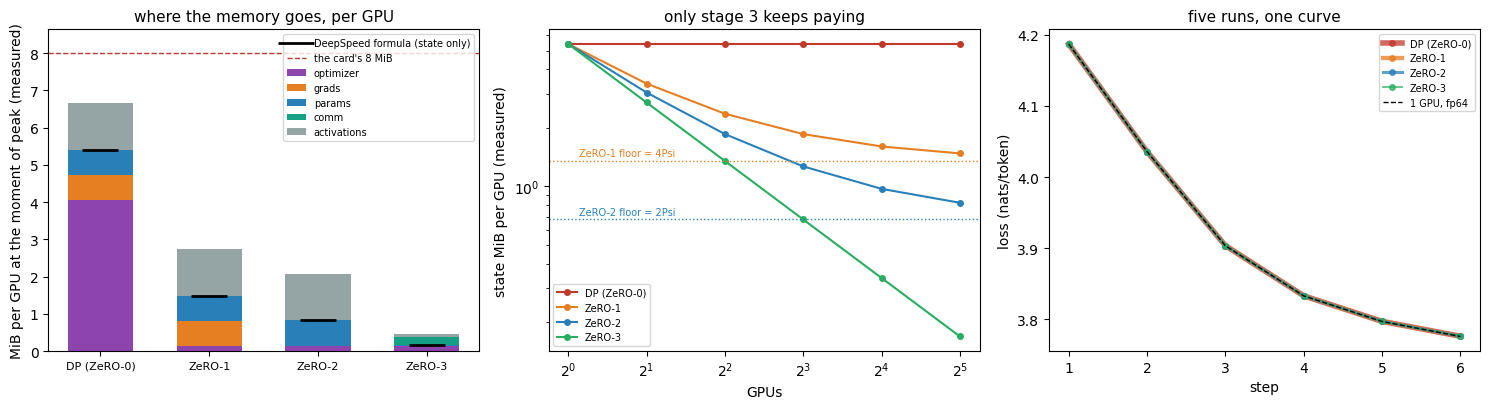

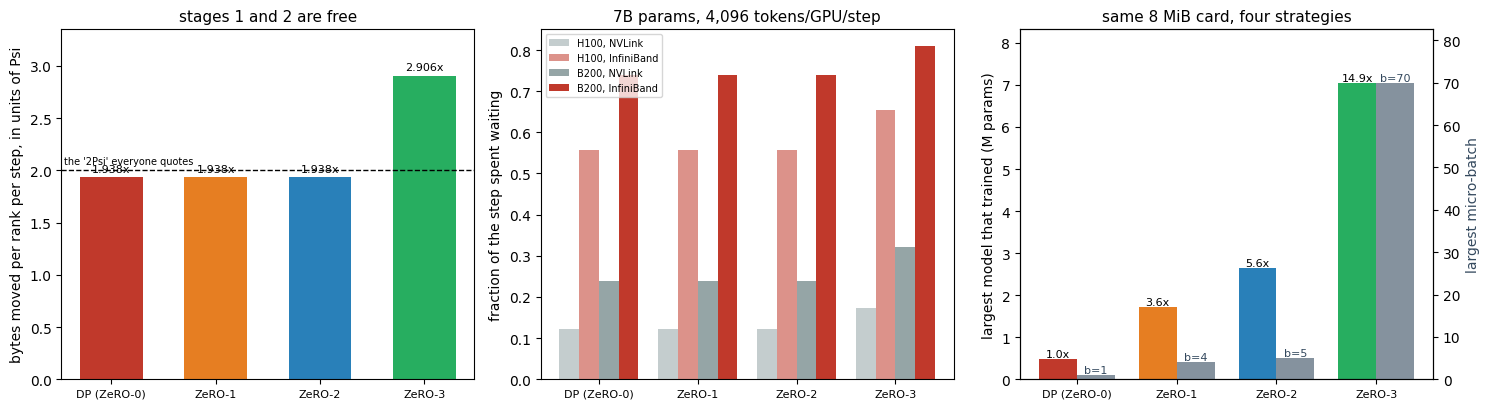

In [16]:
rule("Figures")
COLORS = {0: "#c0392b", 1: "#e67e22", 2: "#2980b9", 3: "#27ae60"}
CATS = [("optimizer", "#8e44ad"), ("grads", "#e67e22"), ("params", "#2980b9"),
        ("comm", "#16a085"), ("activations", "#95a5a6")]

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

# (a) where the memory goes, measured
xs = np.arange(4)
bottom = np.zeros(4)
# `peak_snapshot` is what the ledger held at the instant of its high-water mark, so the
# segments add up to the bar.  `by_cat` -- each category's own maximum -- does not: the
# reduce-scatter bucket and the activations peak at different moments, and stacking them
# draws a rank that never existed.
for cat, colour in CATS:
    vals = np.array([(runs[s]["peak_snapshot"] or {}).get(cat, 0) / MIB for s in (0, 1, 2, 3)])
    ax[0].bar(xs, vals, 0.6, bottom=bottom, label=cat, color=colour)
    bottom += vals
for s in (0, 1, 2, 3):
    record(f"s{s}_peak_snapshot", runs[s]["peak_snapshot"])
theory = [zero_theory(s, PSI, WORLD) / MIB for s in (0, 1, 2, 3)]
ax[0].plot(xs, theory, "k_", markersize=26, markeredgewidth=2,
           label="DeepSpeed formula (state only)")
ax[0].axhline(GPU_CAPACITY / MIB, color="#c0392b", ls="--", lw=1,
              label="the card's 8 MiB")
ax[0].set_xticks(xs)
ax[0].set_xticklabels([STAGE_NAMES[s] for s in (0, 1, 2, 3)], fontsize=8)
ax[0].set_ylabel("MiB per GPU at the moment of peak (measured)")
ax[0].set_ylim(0, GPU_CAPACITY / MIB * 1.08)
ax[0].set_title("where the memory goes, per GPU", fontsize=11)
ax[0].legend(fontsize=7, loc="upper right")

# (b) memory per GPU as the world grows
for s in (0, 1, 2, 3):
    ax[1].plot([r["world"] for r in scale_rows[s]],
               [r["state"] / MIB for r in scale_rows[s]], "o-",
               color=COLORS[s], label=STAGE_NAMES[s], ms=4)
ax[1].axhline(4 * PSI / MIB, color=COLORS[1], ls=":", lw=1)
ax[1].text(1.1, 4 * PSI / MIB * 1.06, "ZeRO-1 floor = 4Psi", fontsize=7, color=COLORS[1])
ax[1].axhline(2 * PSI / MIB, color=COLORS[2], ls=":", lw=1)
ax[1].text(1.1, 2 * PSI / MIB * 1.06, "ZeRO-2 floor = 2Psi", fontsize=7, color=COLORS[2])
ax[1].set_xscale("log", base=2)
ax[1].set_yscale("log")
ax[1].set_xlabel("GPUs")
ax[1].set_ylabel("state MiB per GPU (measured)")
ax[1].set_title("only stage 3 keeps paying", fontsize=11)
ax[1].legend(fontsize=7)

# (c) the four stages train the same model
for s in (0, 1, 2, 3):
    ax[2].plot(range(1, EQ_STEPS + 1), eq["bf16/fp32"][s]["losses"], "o-",
               color=COLORS[s], label=STAGE_NAMES[s], ms=4, alpha=0.75,
               lw=4 - s * 0.9)
ax[2].plot(range(1, EQ_STEPS + 1), eq["float64"]["ref_losses"], "k--", lw=1,
           label="1 GPU, fp64")
ax[2].set_xlabel("step")
ax[2].set_ylabel("loss (nats/token)")
ax[2].set_title("five runs, one curve", fontsize=11)
ax[2].legend(fontsize=7)

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "memory.png"), dpi=130)
show(fig)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

# (a) communication volume
vols = [runs[s]["comm_per_rank"] / PSI_BYTES for s in (0, 1, 2, 3)]
bars = ax[0].bar(xs, vols, 0.6, color=[COLORS[s] for s in (0, 1, 2, 3)])
for x, v in zip(xs, vols):
    ax[0].text(x, v + 0.05, f"{v:.3f}x", ha="center", fontsize=8)
ax[0].axhline(2, color="k", ls="--", lw=1)
ax[0].text(-0.45, 2.06, "the '2Psi' everyone quotes", fontsize=7, ha="left")
ax[0].set_ylim(0, 3.35)
ax[0].set_xticks(xs)
ax[0].set_xticklabels([STAGE_NAMES[s] for s in (0, 1, 2, 3)], fontsize=8)
ax[0].set_ylabel("bytes moved per rank per step, in units of Psi")
ax[0].set_title("stages 1 and 2 are free", fontsize=11)

# (b) the bubble
width = 0.2
for j, (hw, _) in enumerate(HARDWARE):
    for k, link in enumerate(["NVLink, 1 node", "InfiniBand, 4 nodes"]):
        vals = [[p for p in proj if p["stage"] == s and p["hw"] == hw
                 and p["link"] == link][0]["bubble"] for s in (0, 1, 2, 3)]
        ax[1].bar(xs + (j * 2 + k - 1.5) * width, vals, width,
                  label=f"{hw}, {link.split(',')[0]}",
                  color=["#95a5a6", "#c0392b"][k], alpha=[0.55, 1.0][j])
ax[1].set_xticks(xs)
ax[1].set_xticklabels([STAGE_NAMES[s] for s in (0, 1, 2, 3)], fontsize=8)
ax[1].set_ylabel("fraction of the step spent waiting")
ax[1].set_title(f"{PROJ_PSI / 1e9:.0f}B params, {PROJ_TOKENS:,} tokens/GPU/step",
                fontsize=11)
ax[1].legend(fontsize=7)

# (c) capacity
w2 = 0.38
ax[2].bar(xs - w2 / 2, [r["psi"] / 1e6 for r in cap_rows], w2,
          color=[COLORS[s] for s in (0, 1, 2, 3)], label="widest model (M params)")
ax[2].set_ylabel("largest model that trained (M params)")
ax[2].set_xticks(xs)
ax[2].set_xticklabels([STAGE_NAMES[s] for s in (0, 1, 2, 3)], fontsize=8)
ax[2].set_ylim(0, max(r["psi"] for r in cap_rows) / 1e6 * 1.18)
ax2b = ax[2].twinx()
ax2b.bar(xs + w2 / 2, [r["bsz"] for r in bsz_rows], w2, color="#34495e", alpha=0.6)
ax2b.set_ylabel("largest micro-batch", color="#34495e")
ax2b.set_ylim(0, max(r["bsz"] for r in bsz_rows) * 1.18)
for x, r in zip(xs, cap_rows):
    ax[2].text(x - w2 / 2, r["psi"] / 1e6, f"{r['vs_dp']:.1f}x", ha="center",
               va="bottom", fontsize=8)
for x, r in zip(xs, bsz_rows):
    ax2b.text(x + w2 / 2, r["bsz"], f"b={r['bsz']:.0f}", ha="center", va="bottom",
              fontsize=8, color="#34495e")
ax[2].set_title("same 8 MiB card, four strategies", fontsize=11)

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "communication.png"), dpi=130)
show(fig)

## 14. What I would actually do with this

Four opinions, of which the measurements changed two.

**Go to ZeRO-2 unconditionally.** It is free — not cheap, free, to the byte — and it
returns most of the memory ZeRO has to give. There is no trade to weigh, and I went in
expecting there to be one. Anything still on plain data parallelism is leaving memory on
the floor for nothing.

**ZeRO-3 is a decision about the wire, not about the model.** Its extra 50% of traffic is
noise inside a node and most of the step across InfiniBand. "Should we use ZeRO-3" is not
answerable before "is this one box or four", and I would have got that ordering backwards.

**Before reaching for ZeRO-3, look at the gathered bucket and at the block width**, because
at 32 GPUs the bucket was larger than everything the shards held. Deeper-and-narrower at
constant parameter count is a sharding decision wearing an architecture decision's clothes.

**Then stop optimising state and go after activations**, which is where the memory that is
left actually is, and which no ZeRO stage touches. That is the next session's problem, and
it is a different axis: gradient checkpointing, sequence parallelism, reversibility.

And one thing I would say to anyone quoting the table: **`16Psi/N` is the state, not the
peak.** Every real ZeRO-3 run also holds one whole layer, and that term does not shrink
when you buy more GPUs.

In [17]:
rule("Done")
ELAPSED = time.time() - T_START
record("elapsed_s", round(ELAPSED, 1))
record("n_results_keys", len(RESULTS) + 1)
with open(os.path.join(OUT_DIR, "results.json"), "w", encoding="utf-8") as f:
    json.dump(RESULTS, f, indent=1, default=float, ensure_ascii=False)
print(f"wrote results/results.json  ({len(RESULTS)} recorded values)")
print(f"figures: memory.png, communication.png")
print(f"elapsed: {ELAPSED / 60:.1f} minutes on {RESULTS['host_cores']} CPU cores")
print(f"""
the answers, in one place
-------------------------
1. 32 virtual GPUs, 4 nodes of 8, with a hard {GPU_CAPACITY / MIB:.0f} MiB ceiling each and
   ring collectives run over 32 threads.  The ring reproduces a plain sum to
   {RESULTS['ar_digits']:.1f} digits and moves {RESULTS['ar_bytes_per_rank_over_psi']:.4f}xPsi
   per rank per all-reduce -- the (N-1)/N that the "2Psi" shorthand drops.
2. Memory measured, not derived: {RESULTS['s0_state'] / MIB:.3f} /
   {RESULTS['s1_state'] / MIB:.3f} / {RESULTS['s2_state'] / MIB:.3f} /
   {RESULTS['s3_state'] / MIB:.3f} MiB per GPU for stages 0/1/2/3, which is
   {RESULTS['s1_saving']:.2f}x, {RESULTS['s2_saving']:.2f}x and {RESULTS['s3_saving']:.0f}x
   less than plain data parallelism, and agrees with the DeepSpeed formula to
   {RESULTS['state_vs_theory_worst']:.2%}.
3. All four stages reproduce a single GPU's weights to
   {RESULTS['eq_f64_worst_digits']:.1f} digits in float64 after {EQ_STEPS} steps, and each
   other to {RESULTS['eq_mixed_stage_weight_spread']:.1e} in the bf16 run you would launch.
   They are one algorithm.
4. Communication: stages 1 and 2 move EXACTLY what stage 0 moves
   ({RESULTS['s0_comm_psi']:.4f}xPsi), so {RESULTS['s2_saving']:.1f}x the memory is free.
   Stage 3 moves {RESULTS['s3_comm_psi']:.4f}xPsi -- 1.5x - which is
   {RESULTS['bubble_s3_h100_nv']:.1%} of a step on NVLink and
   {RESULTS['bubble_s3_h100_ib']:.0%} across InfiniBand.
5. ZeRO-3's peak is NOT 16Psi/N: the gathered bucket is
   {RESULTS['s3_transient_over_state']:.2f}x everything it stores permanently, does not
   shrink with N, and is set by the largest block -- an architecture decision.
6. Grown until it broke: ZeRO-3 trained {RESULTS['cap_s3_over_dp']:.1f}x the parameters and
   {RESULTS['bsz_s3'] / RESULTS['bsz_dp']:.0f}x the micro-batch of plain data parallelism on
   the same card.
""")


Done   [t+5m02s]
wrote results/results.json  (150 recorded values)
figures: memory.png, communication.png
elapsed: 5.0 minutes on 16 CPU cores

the answers, in one place
-------------------------
1. 32 virtual GPUs, 4 nodes of 8, with a hard 8 MiB ceiling each and
   ring collectives run over 32 threads.  The ring reproduces a plain sum to
   15.3 digits and moves 1.9375xPsi
   per rank per all-reduce -- the (N-1)/N that the "2Psi" shorthand drops.
2. Memory measured, not derived: 5.407 /
   1.478 / 0.824 /
   0.169 MiB per GPU for stages 0/1/2/3, which is
   3.66x, 6.56x and 32x
   less than plain data parallelism, and agrees with the DeepSpeed formula to
   0.00%.
3. All four stages reproduce a single GPU's weights to
   13.8 digits in float64 after 6 steps, and each
   other to 9.3e-10 in the bf16 run you would launch.
   They are one algorithm.
4. Communication: stages 1 and 2 move EXACTLY what stage 0 moves
   (1.9375xPsi), so 6.6x the memory is free.
   Stage 3 moves 2.9062xPsi 